In [2]:
# ============================================================
# GUARD Connection — 前段AI 前処理パイプライン
# Cell 1: インポート・定数定義
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from pathlib import Path

# ── パス定数 ──────────────────────────────────────────────────
DATA_ROOT = Path("/kaggle/input/datasets/nagisa2/bidmc-ppg-and-respiration/bidmc-ppg-and-respiration-dataset-1.0.0/bidmc_csv")
OUTPUT_ROOT = Path("/kaggle/working/spectrograms")

# ── 信号定数 ──────────────────────────────────────────────────
FS = 125          # サンプリングレート (Hz)
SEG_SEC = 10      # セグメント長 (秒)
SEG_LEN = FS * SEG_SEC   # = 1250 サンプル
OVERLAP_RATIO = 0.5
HOP_LEN = int(SEG_LEN * (1 - OVERLAP_RATIO))  # = 625 サンプル

# ── スペクトログラム定数（後でパラメータ最適化する） ──────────
NPERSEG = 128     # FFT窓長
NOVERLAP = 96     # オーバーラップ (75%)
IMG_H = 64        # 周波数ビン数（リサイズ後）
IMG_W = 64        # 時間ビン数（リサイズ後）

print(f"SEG_LEN: {SEG_LEN} samples = {SEG_SEC} sec @ {FS} Hz")
print(f"HOP_LEN: {HOP_LEN} samples = {SEG_SEC * OVERLAP_RATIO} sec")
print(f"DATA_ROOT exists: {DATA_ROOT.exists()}")

SEG_LEN: 1250 samples = 10 sec @ 125 Hz
HOP_LEN: 625 samples = 5.0 sec
DATA_ROOT exists: True


In [3]:
# ============================================================
# Cell 2: 1被験者分の読み込み・カラム確認
# ============================================================

def load_signals(subject_id: int) -> pd.DataFrame | None:
    """
    bidmc_XX_Signals.csv を読み込み、PPG・ECG列を返す。
    カラム名の先頭スペースをstripし、クリッピング状況を報告する。
    """
    fname = DATA_ROOT / f"bidmc_{subject_id:02d}_Signals.csv"
    if not fname.exists():
        return None

    df = pd.read_csv(fname)
    df.columns = df.columns.str.strip()  # 先頭スペース除去

    # カラム名確認（初回のみ表示）
    return df


# ── 被験者01で構造確認 ────────────────────────────────────────
df_sample = load_signals(1)
print("=== カラム一覧 ===")
print(df_sample.columns.tolist())
print(f"\n=== shape ===")
print(df_sample.shape)
print(f"\n=== 先頭5行 ===")
print(df_sample.head())

=== カラム一覧 ===
['Time [s]', 'RESP', 'PLETH', 'V', 'AVR', 'II']

=== shape ===
(60001, 6)

=== 先頭5行 ===
   Time [s]     RESP    PLETH        V      AVR       II
0     0.000  0.35386  0.43597  0.52549  0.30392  0.72549
1     0.008  0.35679  0.43206  0.51961  0.33529  0.67059
2     0.016  0.35875  0.42815  0.51569  0.37451  0.60980
3     0.024  0.36168  0.42424  0.50588  0.41961  0.55098
4     0.032  0.36364  0.42131  0.50980  0.44902  0.50000


ecg_range: (np.float32(-0.50196), np.float32(1.5039))
ppg_range: (np.float32(0.22385), np.float32(0.69795))
ecg_clip_ratio: 0.025716238062698956
ppg_clip_ratio: 0.00013333111114814753
n_samples: 60001
nan_ecg: 0
nan_ppg: 0


/tmp/ipykernel_59/83828619.py:59: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59/83828619.py:59: UserWarning: Glyph 21021 (\N{CJK UNIFIED IDEOGRAPH-521D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59/83828619.py:59: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59/83828619.py:59: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59/83828619.py:59: UserWarning: Glyph 20505 (\N{CJK UNIFIED IDEOGRAPH-5019}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59/83828619.py:59: UserWarning: Glyph 35036 (\N{CJK UNIFIED IDEOGRAPH-88DC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59/83828619.py:59: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  plt.ti

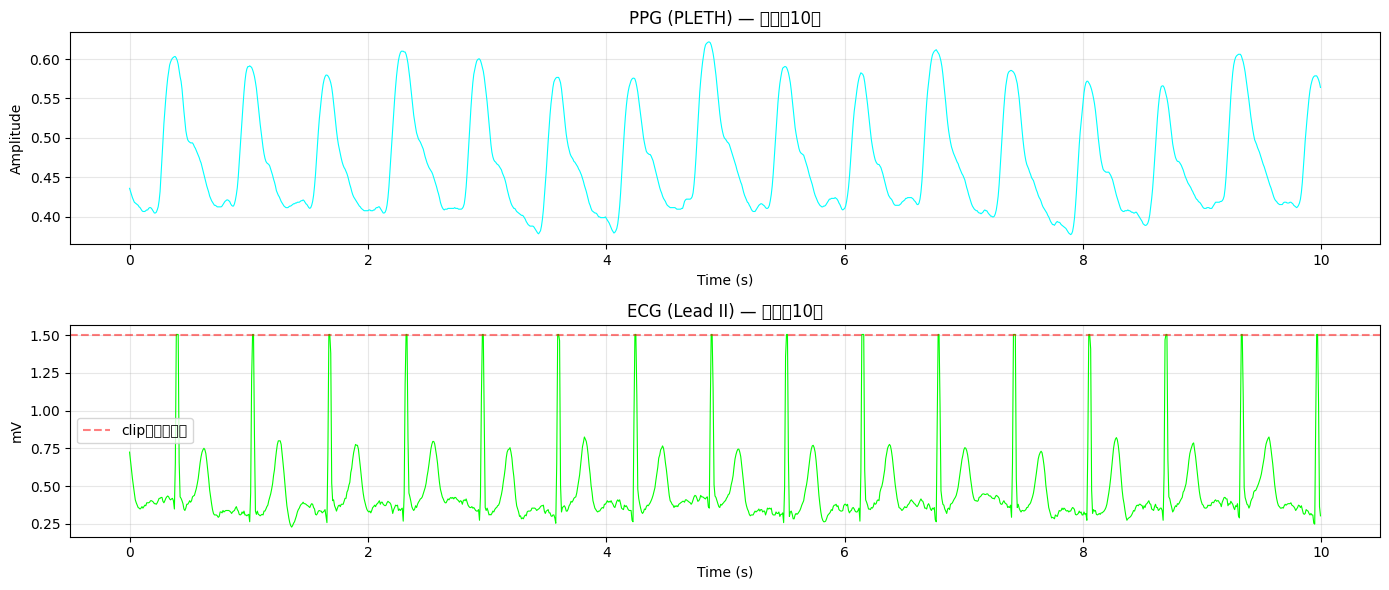

In [4]:
# ============================================================
# Cell 3: クリッピング・信号品質の確認
# ============================================================

def check_signal_quality(df: pd.DataFrame, ppg_col: str, ecg_col: str) -> dict:
    ppg = df[ppg_col].values.astype(np.float32)
    ecg = df[ecg_col].values.astype(np.float32)

    ecg_max = ecg.max()
    ecg_min = ecg.min()
    ppg_max = ppg.max()
    ppg_min = ppg.min()

    # クリッピング検出: 最大値付近に集中しすぎていないか
    clip_threshold = 0.99
    ecg_clip_ratio = (np.abs(ecg) >= ecg_max * clip_threshold).mean()
    ppg_clip_ratio = (np.abs(ppg) >= ppg_max * clip_threshold).mean()

    return {
        "ecg_range": (ecg_min, ecg_max),
        "ppg_range": (ppg_min, ppg_max),
        "ecg_clip_ratio": ecg_clip_ratio,
        "ppg_clip_ratio": ppg_clip_ratio,
        "n_samples": len(ecg),
        "nan_ecg": np.isnan(ecg).sum(),
        "nan_ppg": np.isnan(ppg).sum(),
    }

# ── カラム名は上のセルの確認後に修正すること ──────────────────
# BIDMCの標準的なカラム名（strip後）
PPG_COL = "PLETH"
ECG_COL = "II"

quality = check_signal_quality(df_sample, PPG_COL, ECG_COL)
for k, v in quality.items():
    print(f"{k}: {v}")

# ── 波形プロット（最初の10秒） ────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6))
t = np.arange(SEG_LEN) / FS

ppg_raw = df_sample[PPG_COL].values[:SEG_LEN].astype(np.float32)
ecg_raw = df_sample[ECG_COL].values[:SEG_LEN].astype(np.float32)

ax1.plot(t, ppg_raw, color="cyan", linewidth=0.8)
ax1.set_title("PPG (PLETH) — 最初の10秒")
ax1.set_ylabel("Amplitude")
ax1.set_xlabel("Time (s)")
ax1.grid(alpha=0.3)

ax2.plot(t, ecg_raw, color="lime", linewidth=0.8)
ax2.set_title("ECG (Lead II) — 最初の10秒")
ax2.set_ylabel("mV")
ax2.set_xlabel("Time (s)")
ax2.axhline(y=1.5, color='red', linestyle='--', alpha=0.5, label='clip候補ライン')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/signal_check_s01.png", dpi=100)
plt.show()

In [5]:
# ============================================================
# Cell 4: 前処理関数定義
# ============================================================

def bandpass_filter(sig: np.ndarray, fs: int, lowcut: float, highcut: float,
                    order: int = 4) -> np.ndarray:
    """バターワースバンドパスフィルタ"""
    nyq = fs / 2.0
    b, a = signal.butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return signal.filtfilt(b, a, sig).astype(np.float32)


def normalize_minmax(sig: np.ndarray) -> np.ndarray:
    """[0, 1] に正規化（スペクトログラム画像生成用）"""
    mn, mx = sig.min(), sig.max()
    if mx - mn < 1e-8:
        return np.zeros_like(sig, dtype=np.float32)
    return ((sig - mn) / (mx - mn)).astype(np.float32)


def preprocess_segment(ppg_seg: np.ndarray, ecg_seg: np.ndarray,
                       fs: int = FS) -> tuple[np.ndarray, np.ndarray]:
    """
    1セグメント分のPPG・ECGを前処理する。
    PPG: 0.5–4 Hz（心拍帯域）
    ECG: 0.5–40 Hz（QRS保持）
    """
    ppg_filtered = bandpass_filter(ppg_seg, fs, lowcut=0.5, highcut=4.0)
    ecg_filtered = bandpass_filter(ecg_seg, fs, lowcut=0.5, highcut=40.0)

    ppg_norm = normalize_minmax(ppg_filtered)
    ecg_norm = normalize_minmax(ecg_filtered)

    return ppg_norm, ecg_norm


# ── 動作確認 ──────────────────────────────────────────────────
ppg_test = df_sample[PPG_COL].values[:SEG_LEN].astype(np.float32)
ecg_test = df_sample[ECG_COL].values[:SEG_LEN].astype(np.float32)

ppg_proc, ecg_proc = preprocess_segment(ppg_test, ecg_test)
print(f"PPG after preprocess: min={ppg_proc.min():.3f}, max={ppg_proc.max():.3f}")
print(f"ECG after preprocess: min={ecg_proc.min():.3f}, max={ecg_proc.max():.3f}")

PPG after preprocess: min=0.000, max=1.000
ECG after preprocess: min=0.000, max=1.000


PPG spectrogram shape: (64, 64), range: [0.000, 0.920]
ECG spectrogram shape: (64, 64), range: [0.000, 0.945]


/tmp/ipykernel_59/3295562103.py:58: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_59/3295562103.py:59: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from font(s) DejaVu Sans.
  plt.savefig("/kaggle/working/spec_check_s01_seg0.png", dpi=100)


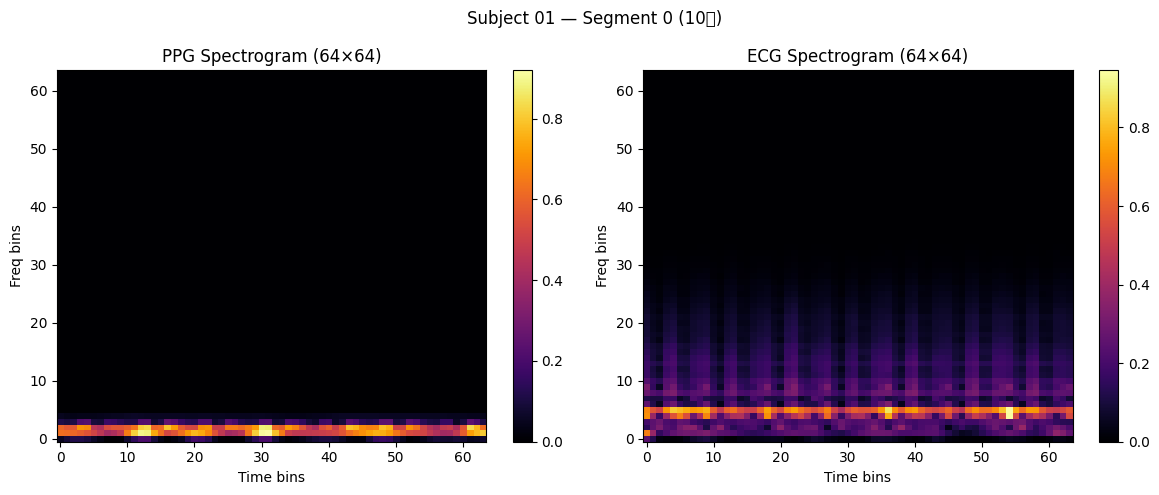

In [6]:
# ============================================================
# Cell 5: スペクトログラム変換・可視化
# ============================================================

from scipy.signal import spectrogram as scipy_spectrogram
from scipy.ndimage import zoom

def signal_to_spectrogram(sig: np.ndarray, fs: int = FS,
                           nperseg: int = NPERSEG,
                           noverlap: int = NOVERLAP,
                           target_h: int = IMG_H,
                           target_w: int = IMG_W) -> np.ndarray:
    """
    1D信号 → 2D スペクトログラム画像 [H, W] (float32, [0,1])
    - log1p スケールで視覚的に均等化
    - 指定サイズにリサイズ
    """
    f, t, Sxx = scipy_spectrogram(sig, fs=fs, nperseg=nperseg,
                                   noverlap=noverlap, window='hann',
                                   scaling='spectrum')

    # 対数スケール変換（数値安定のためlog1p）
    Sxx_log = np.log1p(Sxx).astype(np.float32)

    # [0, 1] 正規化
    Sxx_norm = normalize_minmax(Sxx_log)

    # ターゲットサイズにリサイズ
    zoom_h = target_h / Sxx_norm.shape[0]
    zoom_w = target_w / Sxx_norm.shape[1]
    Sxx_resized = zoom(Sxx_norm, (zoom_h, zoom_w), order=1).astype(np.float32)

    return Sxx_resized


# ── 可視化確認 ────────────────────────────────────────────────
ppg_spec = signal_to_spectrogram(ppg_proc)
ecg_spec = signal_to_spectrogram(ecg_proc)

print(f"PPG spectrogram shape: {ppg_spec.shape}, range: [{ppg_spec.min():.3f}, {ppg_spec.max():.3f}]")
print(f"ECG spectrogram shape: {ecg_spec.shape}, range: [{ecg_spec.min():.3f}, {ecg_spec.max():.3f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(ppg_spec, aspect='auto', origin='lower', cmap='inferno')
axes[0].set_title(f"PPG Spectrogram ({IMG_H}×{IMG_W})")
axes[0].set_xlabel("Time bins")
axes[0].set_ylabel("Freq bins")
plt.colorbar(axes[0].images[0], ax=axes[0])

axes[1].imshow(ecg_spec, aspect='auto', origin='lower', cmap='inferno')
axes[1].set_title(f"ECG Spectrogram ({IMG_H}×{IMG_W})")
axes[1].set_xlabel("Time bins")
axes[1].set_ylabel("Freq bins")
plt.colorbar(axes[1].images[0], ax=axes[1])

plt.suptitle("Subject 01 — Segment 0 (10秒)")
plt.tight_layout()
plt.savefig("/kaggle/working/spec_check_s01_seg0.png", dpi=100)
plt.show()

In [7]:
# ============================================================
# Cell 6: 全データ処理・保存
# Pix2Pix学習用に (PPG_spec, ECG_spec) ペアとして保存
# ============================================================

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

all_ppg_specs = []
all_ecg_specs = []
all_subject_ids = []
all_segment_ids = []

subject_ids = sorted([
    int(re.search(r'bidmc_(\d+)_Signals', f.name).group(1))
    for f in DATA_ROOT.glob("*_Signals.csv")
])

print(f"処理対象被験者数: {len(subject_ids)}")
print(f"被験者ID一覧: {subject_ids}")

for sid in subject_ids:
    df = load_signals(sid)
    if df is None:
        print(f"  [SKIP] subject {sid:02d}: ファイルなし")
        continue

    ppg_full = df[PPG_COL].values.astype(np.float32)
    ecg_full = df[ECG_COL].values.astype(np.float32)

    n_samples = len(ppg_full)
    seg_count = 0

    start = 0
    while start + SEG_LEN <= n_samples:
        ppg_seg = ppg_full[start:start + SEG_LEN]
        ecg_seg = ecg_full[start:start + SEG_LEN]

        # NaN/Inf チェック（破損セグメントをスキップ）
        if np.isnan(ppg_seg).any() or np.isnan(ecg_seg).any():
            start += HOP_LEN
            continue
        if np.isinf(ppg_seg).any() or np.isinf(ecg_seg).any():
            start += HOP_LEN
            continue

        # 前処理
        ppg_norm, ecg_norm = preprocess_segment(ppg_seg, ecg_seg)

        # スペクトログラム変換
        ppg_spec = signal_to_spectrogram(ppg_norm)
        ecg_spec = signal_to_spectrogram(ecg_norm)

        all_ppg_specs.append(ppg_spec)
        all_ecg_specs.append(ecg_spec)
        all_subject_ids.append(sid)
        all_segment_ids.append(seg_count)

        seg_count += 1
        start += HOP_LEN

    print(f"  Subject {sid:02d}: {seg_count} segments, "
          f"n_samples={n_samples}")

# ── numpy配列に変換して保存 ───────────────────────────────────
ppg_arr = np.stack(all_ppg_specs, axis=0)   # (N, H, W)
ecg_arr = np.stack(all_ecg_specs, axis=0)   # (N, H, W)
subj_arr = np.array(all_subject_ids)
seg_arr  = np.array(all_segment_ids)

print(f"\n=== 保存データ ===")
print(f"PPG specs: {ppg_arr.shape}, dtype={ppg_arr.dtype}")
print(f"ECG specs: {ecg_arr.shape}, dtype={ecg_arr.dtype}")
print(f"Total segments: {len(ppg_arr)}")

np.savez_compressed(
    "/kaggle/working/bidmc_spectrograms.npz",
    ppg=ppg_arr,
    ecg=ecg_arr,
    subject_ids=subj_arr,
    segment_ids=seg_arr,
)
print("\n✓ 保存完了: /kaggle/working/bidmc_spectrograms.npz")

処理対象被験者数: 53
被験者ID一覧: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53]
  Subject 01: 95 segments, n_samples=60001
  Subject 02: 95 segments, n_samples=60001
  Subject 03: 95 segments, n_samples=60001
  Subject 04: 95 segments, n_samples=60001
  Subject 05: 95 segments, n_samples=60001
  Subject 06: 95 segments, n_samples=60001
  Subject 07: 95 segments, n_samples=60001
  Subject 08: 95 segments, n_samples=60001
  Subject 09: 95 segments, n_samples=60001
  Subject 10: 95 segments, n_samples=60001
  Subject 11: 95 segments, n_samples=60001
  Subject 12: 95 segments, n_samples=60001
  Subject 13: 95 segments, n_samples=60001
  Subject 14: 95 segments, n_samples=60001
  Subject 15: 95 segments, n_samples=60001
  Subject 16: 95 segments, n_samples=60001
  Subject 17: 95 segments, n_samples=60001
  Subject 18: 95 segments, n_samples=60001


In [8]:
# ============================================================
# Cell 7: 保存確認・被験者単位でtrain/val分割
# ============================================================

data = np.load("/kaggle/working/bidmc_spectrograms.npz")
ppg_arr = data["ppg"]
ecg_arr = data["ecg"]
subj_arr = data["subject_ids"]

print(f"ppg shape: {ppg_arr.shape}")
print(f"ecg shape: {ecg_arr.shape}")
print(f"unique subjects: {np.unique(subj_arr)}")
print(f"total segments: {len(ppg_arr)}")

# ── 被験者単位でtrain/val分割（データリーク防止） ────────────
# 注意: セグメント単位で分割すると同一被験者データが
#       train/valに混在してリークが発生する → 必ず被験者単位で分割
unique_subjects = np.unique(subj_arr)
np.random.seed(42)
np.random.shuffle(unique_subjects)

n_val = max(1, int(len(unique_subjects) * 0.2))  # 約20%をval
val_subjects = set(unique_subjects[:n_val])
train_subjects = set(unique_subjects[n_val:])

train_mask = np.array([s in train_subjects for s in subj_arr])
val_mask   = np.array([s in val_subjects   for s in subj_arr])

print(f"\ntrain subjects ({len(train_subjects)}名): "
      f"{sorted(train_subjects)}")
print(f"val subjects ({len(val_subjects)}名): "
      f"{sorted(val_subjects)}")
print(f"train segments: {train_mask.sum()}")
print(f"val segments:   {val_mask.sum()}")

# 分割保存
np.savez_compressed(
    "/kaggle/working/bidmc_train_v2.npz",
    ppg=ppg_arr[train_mask],
    ecg=ecg_arr[train_mask],
    sid=subj_arr[train_mask]
)

np.savez_compressed(
    "/kaggle/working/bidmc_val_v2.npz",
    ppg=ppg_arr[val_mask],
    ecg=ecg_arr[val_mask],
    sid=subj_arr[val_mask]
)

print("\n✓ train/val 分割保存完了")

ppg shape: (5035, 64, 64)
ecg shape: (5035, 64, 64)
unique subjects: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53]
total segments: 5035

train subjects (43名): [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(43), np.int64(45), np.int64(46), np.int64(47), np.int64(49), np.int64(50), np.int64(52), np.int64(53)]
val subjects (10名): [np.int64(4), np.int64(6), np.int64(13), np.int64(18), np.int64(20), np.int64(33), np.int64(42), np.int64(44

In [9]:
# ============================================================
# Cell 1 修正版 — パラメータ変更
# ============================================================
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import spectrogram as scipy_spectrogram
from scipy.ndimage import zoom
from pathlib import Path

DATA_ROOT   = Path("/kaggle/input/datasets/nagisa2/bidmc-ppg-and-respiration/bidmc-ppg-and-respiration-dataset-1.0.0/bidmc_csv")
OUTPUT_ROOT = Path("/kaggle/working")

FS        = 125
SEG_SEC   = 10
SEG_LEN   = FS * SEG_SEC   # 1250
HOP_LEN   = SEG_LEN // 2   # 625

# ── 修正パラメータ ──────────────────────────────────────────
NPERSEG  = 64    # 窓長を短くして時間分解能を上げる
NOVERLAP = 48    # 75%オーバーラップ
IMG_H    = 64    # 周波数軸（0–62.5Hzを32binに圧縮）
IMG_W    = 128    # 時間軸

PPG_COL = "PLETH"
ECG_COL = "II"

print(f"NPERSEG={NPERSEG} → 周波数分解能: {FS/NPERSEG:.2f} Hz/bin")
print(f"ステップ幅: {NPERSEG - NOVERLAP} samples = {(NPERSEG - NOVERLAP)/FS*1000:.1f} ms")
print(f"10秒セグメントの時間bin数（リサイズ前）: {(SEG_LEN - NOVERLAP) // (NPERSEG - NOVERLAP)}")

NPERSEG=64 → 周波数分解能: 1.95 Hz/bin
ステップ幅: 16 samples = 128.0 ms
10秒セグメントの時間bin数（リサイズ前）: 75


In [11]:
# ============================================================
# 新規セル: 依存パッケージ・再現性設定
# ============================================================
!pip install neurokit2 librosa pytorch-msssim -q

import random
import torch
import neurokit2 as nk

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [12]:
# ============================================================
# Cell 2-6 統合版 — 再生成（品質メタデータ・逆変換用統計付き）
# ============================================================

def load_signals(subject_id):
    fname = DATA_ROOT / f"bidmc_{subject_id:02d}_Signals.csv"
    if not fname.exists():
        return None
    df = pd.read_csv(fname)
    df.columns = df.columns.str.strip()
    return df

def bandpass_filter(sig, fs, lowcut, highcut, order=4):
    nyq = fs / 2.0
    b, a = signal.butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return signal.filtfilt(b, a, sig).astype(np.float32)

def normalize_minmax(sig):
    mn, mx = sig.min(), sig.max()
    if mx - mn < 1e-8:
        return np.zeros_like(sig, dtype=np.float32)
    return ((sig - mn) / (mx - mn)).astype(np.float32)

def normalize_zscore(sig):
    mean, std = np.mean(sig), np.std(sig)
    if std < 1e-8:
        return np.zeros_like(sig, dtype=np.float32)
    return ((sig - mean) / std).astype(np.float32)

def preprocess_segment(ppg_seg, ecg_seg, fs=FS):
    ppg_f = bandpass_filter(ppg_seg, fs, 0.5, 4.0)
    ecg_f = bandpass_filter(ecg_seg, fs, 0.5, 40.0)
    ppg_f = normalize_zscore(ppg_f)
    ecg_f = normalize_zscore(ecg_f)
    return ppg_f, ecg_f

def signal_to_spectrogram(sig, fs=FS, return_stats=False):
    f, t, Sxx = scipy_spectrogram(
        sig, fs=fs, nperseg=NPERSEG, noverlap=NOVERLAP,
        window='hann', scaling='spectrum'
    )
    Sxx = np.maximum(Sxx, 1e-12)
    Sxx_log = np.log1p(Sxx)
    log_min, log_max = float(Sxx_log.min()), float(Sxx_log.max())  # ← 逆変換用に保持

    Sxx_norm = normalize_minmax(Sxx_log.astype(np.float32))
    zh = IMG_H / Sxx_norm.shape[0]
    zw = IMG_W / Sxx_norm.shape[1]
    Sxx_resize = zoom(Sxx_norm, (zh, zw), order=1).astype(np.float32)

    if return_stats:
        return Sxx_resize, log_min, log_max
    return Sxx_resize

def envelope_instability(ppg_seg, fs=FS, win_sec=2.5):  # 1.0 → 2.5に変更
    win = int(fs * win_sec)
    n_win = len(ppg_seg) // win
    if n_win < 2:
        return 0.0
    rms_vals = np.array([
        np.sqrt(np.mean(ppg_seg[i*win:(i+1)*win]**2))
        for i in range(n_win)
    ])
    return float(rms_vals.std() / (rms_vals.mean() + 1e-8))

def pulse_presence_ratio(ppg_seg, fs=FS, win_sec=1.0, rel_threshold=0.3):
    """セグメント内で「パルスが検出できている」時間窓の割合。
    セグメント自身の最大RMSを基準とした相対閾値を使用（旧: percentile*1.5は
    準周期信号で常にほぼ0を返すバグがあったため修正）。
    低いほど断続的接触/一時的信号喪失の疑い。"""
    win = int(fs * win_sec)
    n_win = len(ppg_seg) // win
    if n_win < 2:
        return 1.0
    rms_vals = np.array([
        np.sqrt(np.mean(ppg_seg[i*win:(i+1)*win]**2))
        for i in range(n_win)
    ])
    max_rms = rms_vals.max()
    if max_rms < 1e-8:
        return 0.0
    active_ratio = (rms_vals > rel_threshold * max_rms).mean()
    return float(active_ratio)

def segment_quality_metrics(ppg_seg, ecg_seg, fs=FS):
    """クリッピング比率・R波数・包絡不安定性・パルス存在率など、モデル出力と無関係な客観指標のみ算出"""
    ecg_absmax = np.abs(ecg_seg).max()
    ppg_absmax = np.abs(ppg_seg).max()
    ecg_clip = (np.abs(ecg_seg) >= ecg_absmax * 0.99).mean() if ecg_absmax > 0 else 0.0
    ppg_clip = (np.abs(ppg_seg) >= ppg_absmax * 0.99).mean() if ppg_absmax > 0 else 0.0
    ppg_env_instab = envelope_instability(ppg_seg, fs=fs)
    ppg_pulse_presence = pulse_presence_ratio(ppg_seg, fs=fs)  # ← 追加
    try:
        _, info = nk.ecg_peaks(ecg_seg, sampling_rate=fs)
        n_rpeaks = len(info["ECG_R_Peaks"])
    except Exception:
        n_rpeaks = -1
    return ecg_clip, ppg_clip, float(ecg_seg.std()), n_rpeaks, ppg_env_instab, ppg_pulse_presence  # ← 追加

# ── 全被験者処理 ──────────────────────────────────────────────
subject_ids = sorted([
    int(re.search(r'bidmc_(\d+)_Signals', f.name).group(1))
    for f in DATA_ROOT.glob("*_Signals.csv")
])

all_ppg, all_ecg, all_sid, all_segid = [], [], [], []
all_ecg_clip, all_ppg_clip, all_ecg_std, all_nrpeaks = [], [], [], []
all_ecg_log_min, all_ecg_log_max = [], []
all_ppg_env_instab = []
all_ppg_pulse_presence = []  # ← 追加

for sid in subject_ids:
    df = load_signals(sid)
    ppg_full = df[PPG_COL].values.astype(np.float32)
    ecg_full = df[ECG_COL].values.astype(np.float32)
    n = len(ppg_full)
    seg_count, start = 0, 0

    while start + SEG_LEN <= n:
        ppg_seg = ppg_full[start:start+SEG_LEN]
        ecg_seg = ecg_full[start:start+SEG_LEN]

        if np.isnan(ppg_seg).any() or np.isnan(ecg_seg).any():
            start += HOP_LEN; continue

        # ── 品質メタデータ（除外はしない。記録のみ） ──
        ecg_clip, ppg_clip, ecg_std, n_rpeaks, ppg_env_instab, ppg_pulse_presence = segment_quality_metrics(ppg_seg, ecg_seg)

        ppg_n, ecg_n = preprocess_segment(ppg_seg, ecg_seg)
        ppg_spec = signal_to_spectrogram(ppg_n)
        ecg_spec, ecg_log_min, ecg_log_max = signal_to_spectrogram(ecg_n, return_stats=True)

        all_ppg.append(ppg_spec)
        all_ecg.append(ecg_spec)
        all_sid.append(sid)
        all_segid.append(seg_count)
        all_ecg_clip.append(ecg_clip)
        all_ppg_clip.append(ppg_clip)
        all_ecg_std.append(ecg_std)
        all_nrpeaks.append(n_rpeaks)
        all_ecg_log_min.append(ecg_log_min)
        all_ecg_log_max.append(ecg_log_max)
        all_ppg_env_instab.append(ppg_env_instab)
        all_ppg_pulse_presence.append(ppg_pulse_presence)

        seg_count += 1
        start += HOP_LEN

ppg_arr = np.stack(all_ppg)
ecg_arr = np.stack(all_ecg)
subj_arr = np.array(all_sid)
ecg_clip_arr = np.array(all_ecg_clip)
ppg_clip_arr = np.array(all_ppg_clip)
ecg_std_arr  = np.array(all_ecg_std)
nrpeaks_arr  = np.array(all_nrpeaks)
ecg_log_min_arr = np.array(all_ecg_log_min)
ecg_log_max_arr = np.array(all_ecg_log_max)
ppg_env_instab_arr = np.array(all_ppg_env_instab)
ppg_pulse_presence_arr = np.array(all_ppg_pulse_presence)

print(f"PPG: {ppg_arr.shape}, ECG: {ecg_arr.shape}")
print(f"clip>0.05のセグメント数: {(ecg_clip_arr > 0.05).sum()} / {len(ecg_clip_arr)}")
print(f"R波検出失敗(-1)のセグメント数: {(nrpeaks_arr == -1).sum()}")
print(f"包絡不安定性(env_instab) 統計: mean={ppg_env_instab_arr.mean():.3f}, "
      f"median={np.median(ppg_env_instab_arr):.3f}, "
      f"90%tile={np.percentile(ppg_env_instab_arr,90):.3f}")
print(f"パルス存在率(pulse_presence) 統計: mean={ppg_pulse_presence_arr.mean():.3f}, "  # ← 追加
      f"median={np.median(ppg_pulse_presence_arr):.3f}, "
      f"10%tile={np.percentile(ppg_pulse_presence_arr,10):.3f}")

# ── train/val分割保存（メタデータも同じmaskで分割） ──────────
unique_s = np.unique(subj_arr)
np.random.seed(42)
np.random.shuffle(unique_s)
n_val = max(1, int(len(unique_s) * 0.2))
val_s, train_s = set(unique_s[:n_val]), set(unique_s[n_val:])
train_mask = np.array([s in train_s for s in subj_arr])
val_mask   = np.array([s in val_s   for s in subj_arr])

def save_split(path, mask):
    np.savez_compressed(
        path,
        ppg=ppg_arr[mask], ecg=ecg_arr[mask], sid=subj_arr[mask],
        ecg_clip_ratio=ecg_clip_arr[mask], ppg_clip_ratio=ppg_clip_arr[mask],
        ecg_std=ecg_std_arr[mask], n_rpeaks_raw=nrpeaks_arr[mask],
        ecg_log_min=ecg_log_min_arr[mask], ecg_log_max=ecg_log_max_arr[mask],
        ppg_env_instab=ppg_env_instab_arr[mask],
        ppg_pulse_presence=ppg_pulse_presence_arr[mask],  # ← 追加
    )

save_split("/kaggle/working/bidmc_train_v3.npz", train_mask)
save_split("/kaggle/working/bidmc_val_v3.npz", val_mask)
print(f"train: {train_mask.sum()}, val: {val_mask.sum()}")
print("✓ v3保存完了（品質メタデータ・逆変換統計付き）")

PPG: (5035, 64, 128), ECG: (5035, 64, 128)
clip>0.05のセグメント数: 146 / 5035
R波検出失敗(-1)のセグメント数: 0
包絡不安定性(env_instab) 統計: mean=0.042, median=0.032, 90%tile=0.082
パルス存在率(pulse_presence) 統計: mean=0.999, median=1.000, 10%tile=1.000
train: 4085, val: 950
✓ v3保存完了（品質メタデータ・逆変換統計付き）


In [14]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class SpectrogramDataset(Dataset):
    def __init__(self, npz_path):
        data = np.load(npz_path)

        self.ppg = data["ppg"].astype(np.float32)
        self.ecg = data["ecg"].astype(np.float32)

    def __len__(self):
        return len(self.ppg)

    def __getitem__(self, idx):
        ppg = torch.from_numpy(self.ppg[idx]).unsqueeze(0)
        ecg = torch.from_numpy(self.ecg[idx]).unsqueeze(0)

        # Pix2Pix標準の[-1,1]
        ppg = ppg * 2.0 - 1.0
        ecg = ecg * 2.0 - 1.0

        return ppg, ecg

In [15]:
BATCH_SIZE = 32

train_dataset = SpectrogramDataset("/kaggle/working/bidmc_train_v3.npz")
val_dataset   = SpectrogramDataset("/kaggle/working/bidmc_val_v3.npz")

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, generator=g
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

print(len(train_dataset))
print(len(val_dataset))

4085
950


In [ ]:
# ============================================================
# 新規セル: num_workers=0版DataLoader（再現性検証用）
# ============================================================
train_loader_nw0 = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True, generator=g  # ← num_workersのみ0に変更
)
val_loader_nw0 = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True
)

In [16]:
ppg, ecg = next(iter(train_loader))

print(ppg.shape)
print(ecg.shape)

print(ppg.min(), ppg.max())
print(ecg.min(), ecg.max())

torch.Size([32, 1, 64, 128])
torch.Size([32, 1, 64, 128])
tensor(-1.) tensor(0.9830)
tensor(-1.) tensor(0.9914)


In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=False):
        super().__init__()

        layers = [
            nn.Upsample(
                scale_factor=2,
                mode='bilinear',
                align_corners=False
            ),
            nn.Conv2d(
                in_ch,
                out_ch,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        ]

        if dropout:
            layers.append(nn.Dropout(0.5))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

In [26]:
import torch
import torch.nn as nn


####################################################
# Encoder
####################################################

class UNetDown(nn.Module):
    def __init__(self,
                 in_size,
                 out_size,
                 normalize=True):
        super().__init__()

        layers = [
            nn.Conv2d(
                in_size,
                out_size,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            )
        ]

        if normalize:
            layers.append(
                nn.BatchNorm2d(out_size)
            )

        layers.append(
            nn.LeakyReLU(
                0.2,
                inplace=True
            )
        )

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


####################################################
# Decoder Block
####################################################

class UpBlock(nn.Module):
    def __init__(self,
                 in_ch,
                 out_ch,
                 dropout=False):
        super().__init__()

        layers = [
            nn.Upsample(
                scale_factor=2,
                mode='bilinear',
                align_corners=False
            ),
            nn.Conv2d(
                in_ch,
                out_ch,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        ]

        if dropout:
            layers.append(
                nn.Dropout(0.5)
            )

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


####################################################
# Generator
####################################################

class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()

        ############################
        # Encoder
        ############################

        self.down1 = UNetDown(
            1,
            64,
            normalize=False
        )

        self.down2 = UNetDown(
            64,
            128
        )

        self.down3 = UNetDown(
            128,
            256
        )

        self.down4 = UNetDown(
            256,
            512
        )

        ############################
        # Decoder
        ############################

        self.up1 = UpBlock(
            512,
            256,
            dropout=True
        )

        self.conv1 = nn.Conv2d(
            512,
            256,
            kernel_size=3,
            padding=1
        )

        self.up2 = UpBlock(
            256,
            128,
            dropout=True
        )

        self.conv2 = nn.Conv2d(
            256,
            128,
            kernel_size=3,
            padding=1
        )

        self.up3 = UpBlock(
            128,
            64
        )

        self.conv3 = nn.Conv2d(
            128,
            64,
            kernel_size=3,
            padding=1
        )

        #################################################
        # 追加
        #################################################

        self.up4 = UpBlock(
            64,
            32
        )

        self.final = nn.Sequential(
            nn.Conv2d(
                32,
                1,
                kernel_size=3,
                padding=1
            ),
            nn.Tanh()
        )

    def forward(self, x):

        ############################
        # Encoder
        ############################

        d1 = self.down1(x)   # 16×32
        d2 = self.down2(d1)  # 8×16
        d3 = self.down3(d2)  # 4×8
        d4 = self.down4(d3)  # 2×4

        ############################
        # Decoder
        ############################

        u1 = self.up1(d4)
        u1 = torch.cat(
            [u1, d3],
            dim=1
        )
        u1 = self.conv1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat(
            [u2, d2],
            dim=1
        )
        u2 = self.conv2(u2)

        u3 = self.up3(u2)
        u3 = torch.cat(
            [u3, d1],
            dim=1
        )
        u3 = self.conv3(u3)

        #################################################
        # 16×32 → 32×64
        #################################################

        u4 = self.up4(u3)

        return self.final(u4)

In [27]:
generator = UNetGenerator()

x = torch.randn(
    1,
    1,
    32,
    64
)

y = generator(x)

print(x.shape)
print(y.shape)

torch.Size([1, 1, 32, 64])
torch.Size([1, 1, 32, 64])


In [28]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

generator = UNetGenerator().to(device)

x, y = next(iter(train_loader))

x = x.to(device)

with torch.no_grad():
    pred = generator(x)

print(pred.shape)
print(pred.min(), pred.max())

torch.Size([32, 1, 64, 128])
tensor(-0.9237, device='cuda:0') tensor(0.9403, device='cuda:0')


In [46]:
# ============================================================
# 新規セル: PatchDiscriminator定義（欠落分の補完）
# ============================================================
class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=2):
        super().__init__()

        def block(in_c, out_c, normalize=True):
            layers = [nn.Conv2d(in_c, out_c, kernel_size=4, stride=2,
                                 padding=1, bias=False)]
            if normalize:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(in_channels, 64, normalize=False),
            *block(64, 128),
            *block(128, 256),
            nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=1),
        )

    def forward(self, ppg, ecg):
        x = torch.cat([ppg, ecg], dim=1)
        return self.model(x)

In [53]:
# ============================================================
# 新規セル: 学習ループの関数化（λ_L1グリッドサーチ対応）
# ============================================================
from torch.cuda.amp import autocast, GradScaler
from pytorch_msssim import SSIM

def qrs_weighted_l1(fake, real, freq_bin_start=20, weight=3.0):
    """周波数軸（dim=2, 上が高周波）の上位帯域に重みを付けたL1損失。
    QRS complexは広帯域高周波成分を含むため、この帯域の再現誤差を強調する。"""
    diff = torch.abs(fake - real)  # (B,1,H,W)
    weights = torch.ones_like(diff)
    weights[:, :, freq_bin_start:, :] = weight
    return (diff * weights).mean()

def train_pix2pix(train_loader, val_loader, lambda_l1=50, lambda_ssim=10,
                   epochs=50, patience=20, min_delta=0.001,
                   lr_g=2e-4, lr_d=5e-5, save_path=None, seed=42, verbose=True,
                   use_qrs_weighted_l1=False, qrs_freq_bin_start=20, qrs_weight=3.0,
                   use_amp=True, log_every=5):  # ← 追加

    set_seed(seed)

    generator = UNetGenerator().to(device)
    discriminator = PatchDiscriminator().to(device)

    criterion_GAN = nn.BCEWithLogitsLoss()
    criterion_L1 = nn.L1Loss()
    ssim_module = SSIM(data_range=2.0, size_average=True, channel=1)

    optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr_g, betas=(0.5, 0.999))
    optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr_d, betas=(0.5, 0.999))
    scaler_G, scaler_D = GradScaler(), GradScaler()

    x0, y0 = next(iter(train_loader))
    with torch.no_grad():
        patch = discriminator(x0.to(device), y0.to(device)).shape[2:]

    history = {"train_g": [], "train_d": [], "val_g": [], "val_d": []}
    best_val, counter = np.inf, 0

    for epoch in range(epochs):
        generator.train(); discriminator.train()
        g_sum = d_sum = 0.0

        for ppg, real_ecg in train_loader:
            ppg, real_ecg = ppg.to(device), real_ecg.to(device)
            bs = ppg.size(0)
            valid = torch.full((bs, 1, *patch), 0.9, device=device)
            fake  = torch.full((bs, 1, *patch), 0.1, device=device)

            optimizer_D.zero_grad()
            with autocast():
                fake_ecg = generator(ppg)
                loss_D = 0.5 * (
                    criterion_GAN(discriminator(ppg, real_ecg), valid) +
                    criterion_GAN(discriminator(ppg, fake_ecg.detach()), fake)
                )
            scaler_D.scale(loss_D).backward()
            scaler_D.step(optimizer_D); scaler_D.update()

            optimizer_G.zero_grad()
            with autocast(enabled=use_amp):
                fake_ecg = generator(ppg)
                loss_GAN = criterion_GAN(discriminator(ppg, fake_ecg), valid)
                if use_qrs_weighted_l1:  # ← 追加
                    loss_L1 = qrs_weighted_l1(fake_ecg, real_ecg,
                                               freq_bin_start=qrs_freq_bin_start,
                                               weight=qrs_weight)
                else:
                    loss_L1 = criterion_L1(fake_ecg, real_ecg)
                loss_SSIM = 1.0 - ssim_module(fake_ecg, real_ecg)
                loss_G = loss_GAN + lambda_l1 * loss_L1 + lambda_ssim * loss_SSIM
            scaler_G.scale(loss_G).backward()
            scaler_G.step(optimizer_G); scaler_G.update()

            g_sum += loss_G.item(); d_sum += loss_D.item()

        history["train_g"].append(g_sum / len(train_loader))
        history["train_d"].append(d_sum / len(train_loader))

        generator.eval(); discriminator.eval()
        vg_sum = vd_sum = 0.0
        with torch.no_grad():
            for ppg, real_ecg in val_loader:
                ppg, real_ecg = ppg.to(device), real_ecg.to(device)
                bs = ppg.size(0)
                valid = torch.full((bs, 1, *patch), 0.9, device=device)
                fake  = torch.full((bs, 1, *patch), 0.1, device=device)
                fake_ecg = generator(ppg)
                loss_D_val = 0.5 * (
                    criterion_GAN(discriminator(ppg, real_ecg), valid) +
                    criterion_GAN(discriminator(ppg, fake_ecg), fake)
                )
                loss_GAN = criterion_GAN(discriminator(ppg, fake_ecg), valid)
                if use_qrs_weighted_l1:  # ← 追加
                    loss_L1 = qrs_weighted_l1(fake_ecg, real_ecg,
                                               freq_bin_start=qrs_freq_bin_start,
                                               weight=qrs_weight)
                else:
                    loss_L1 = criterion_L1(fake_ecg, real_ecg)
                loss_SSIM = 1.0 - ssim_module(fake_ecg, real_ecg)
                loss_G_val = loss_GAN + lambda_l1 * loss_L1 + lambda_ssim * loss_SSIM
                vg_sum += loss_G_val.item(); vd_sum += loss_D_val.item()

        history["val_g"].append(vg_sum / len(val_loader))
        history["val_d"].append(vd_sum / len(val_loader))

        if history["val_g"][-1] < best_val - min_delta:
            best_val, counter = history["val_g"][-1], 0
            if save_path:
                torch.save(generator.state_dict(), save_path)
        else:
            counter += 1

        if verbose and (epoch == 0 or epoch == epochs - 1 or (epoch + 1) % log_every == 0):
            print(f"[λL1={lambda_l1}] Epoch {epoch+1}/{epochs} "
                  f"TrainG={history['train_g'][-1]:.4f} ValG={history['val_g'][-1]:.4f}")

        if counter >= patience:
            print("Early stopping"); break

    return generator, discriminator, history

In [22]:
# ============================================================
# 新規セル: Step1 — λ_L1スクリーニング（各15epoch）
# ============================================================
lambda_candidates = [50, 20, 10, 5]
screening = {}

for lam in lambda_candidates:
    gen, disc, hist = train_pix2pix(
        train_loader, val_loader,
        lambda_l1=lam, lambda_ssim=10, epochs=15, patience=15,
        save_path=f"/kaggle/working/gen_lambda{lam}_screen.pth",
        verbose=False
    )
    screening[lam] = {"generator": gen, "history": hist}
    print(f"λL1={lam}: TrainG(last)={hist['train_g'][-1]:.4f} "
          f"ValG(last)={hist['val_g'][-1]:.4f}")

plt.figure(figsize=(8,5))
for lam, r in screening.items():
    plt.plot(r["history"]["val_g"], label=f"λL1={lam}")
plt.xlabel("Epoch"); plt.ylabel("Val G Loss"); plt.legend(); plt.grid()
plt.title("λ_L1スクリーニング比較")
plt.savefig("/kaggle/working/lambda_screening.png", dpi=150)
plt.show()

/tmp/ipykernel_58/3182009535.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_G, scaler_D = GradScaler(), GradScaler()
/tmp/ipykernel_58/3182009535.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_58/3182009535.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


KeyboardInterrupt: 

In [57]:
# ============================================================
# 新規セル: AMP無効化での再現性検証（C章で追加したuse_ampを使用）
# ============================================================
BEST_LAMBDA_L1 = 20

generator_noamp, discriminator_noamp, history_noamp = train_pix2pix(
    train_loader, val_loader,
    lambda_l1=BEST_LAMBDA_L1, lambda_ssim=10,
    epochs=50, patience=20,
    save_path="/kaggle/working/best_generator_noamp.pth",
    verbose=True, use_amp=False
)
generator_noamp.load_state_dict(torch.load("/kaggle/working/best_generator_noamp.pth"))
generator_noamp.eval()

/tmp/ipykernel_59/3182009535.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_G, scaler_D = GradScaler(), GradScaler()
/tmp/ipykernel_59/3182009535.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_59/3182009535.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


[λL1=20] Epoch 1/50 TrainG=7.6727 ValG=5.3489
[λL1=20] Epoch 5/50 TrainG=3.8675 ValG=4.7340
[λL1=20] Epoch 10/50 TrainG=3.3691 ValG=4.5327
[λL1=20] Epoch 15/50 TrainG=2.9666 ValG=3.8865
[λL1=20] Epoch 20/50 TrainG=2.7954 ValG=5.9857
[λL1=20] Epoch 25/50 TrainG=2.6879 ValG=4.6893
[λL1=20] Epoch 30/50 TrainG=2.3977 ValG=3.9774
[λL1=20] Epoch 35/50 TrainG=2.2944 ValG=4.4750
[λL1=20] Epoch 40/50 TrainG=2.2013 ValG=4.1995
[λL1=20] Epoch 45/50 TrainG=2.1608 ValG=3.9725
[λL1=20] Epoch 50/50 TrainG=2.1617 ValG=4.5415


UNetGenerator(
  (down1): UNetDown(
    (model): Sequential(
      (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): LeakyReLU(negative_slope=0.2, inplace=True)
    )
  )
  (down2): UNetDown(
    (model): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
  )
  (down3): UNetDown(
    (model): Sequential(
      (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
  )
  (down4): UNetDown(
    (model): Sequential(
      (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=Tr

In [60]:
# ============================================================
# 新規セル: 本番学習（screeningで選定したλ_L1を使用）
# ============================================================
BEST_LAMBDA_L1 = 20

# ── 通常版（比較のベースライン。既存結果と同一設定） ──
generator, discriminator, history = train_pix2pix(
    train_loader, val_loader,
    lambda_l1=BEST_LAMBDA_L1, lambda_ssim=10,
    epochs=50, patience=20,
    save_path="/kaggle/working/best_generator.pth",
    verbose=True, use_qrs_weighted_l1=False
)
generator.load_state_dict(torch.load("/kaggle/working/best_generator.pth"))
generator.eval()

/tmp/ipykernel_59/3182009535.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_G, scaler_D = GradScaler(), GradScaler()
/tmp/ipykernel_59/3182009535.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_59/3182009535.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


[λL1=20] Epoch 1/50 TrainG=8.2197 ValG=4.7530
[λL1=20] Epoch 5/50 TrainG=3.4761 ValG=4.7331
[λL1=20] Epoch 10/50 TrainG=3.0024 ValG=3.7507
[λL1=20] Epoch 15/50 TrainG=2.6388 ValG=7.5811
[λL1=20] Epoch 20/50 TrainG=2.5294 ValG=5.1018
[λL1=20] Epoch 25/50 TrainG=2.5006 ValG=4.5701
[λL1=20] Epoch 30/50 TrainG=2.2253 ValG=4.2141
[λL1=20] Epoch 35/50 TrainG=2.1169 ValG=5.1411
[λL1=20] Epoch 40/50 TrainG=2.0971 ValG=4.3119
[λL1=20] Epoch 45/50 TrainG=2.0274 ValG=4.0424
[λL1=20] Epoch 50/50 TrainG=2.0328 ValG=3.8037


UNetGenerator(
  (down1): UNetDown(
    (model): Sequential(
      (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): LeakyReLU(negative_slope=0.2, inplace=True)
    )
  )
  (down2): UNetDown(
    (model): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
  )
  (down3): UNetDown(
    (model): Sequential(
      (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
  )
  (down4): UNetDown(
    (model): Sequential(
      (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=Tr

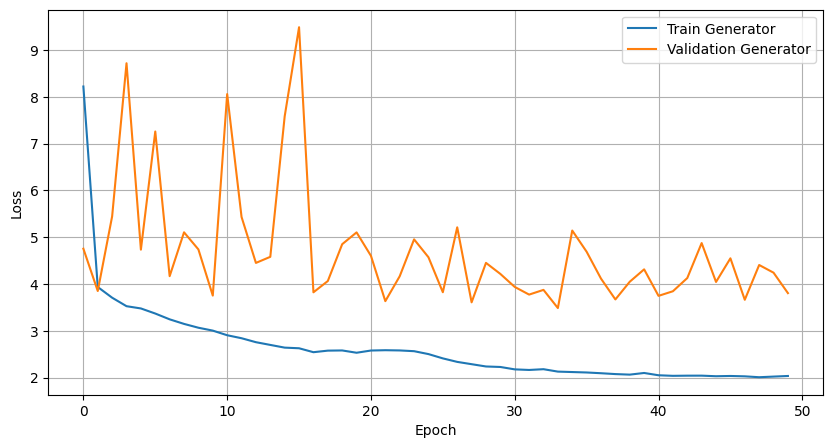

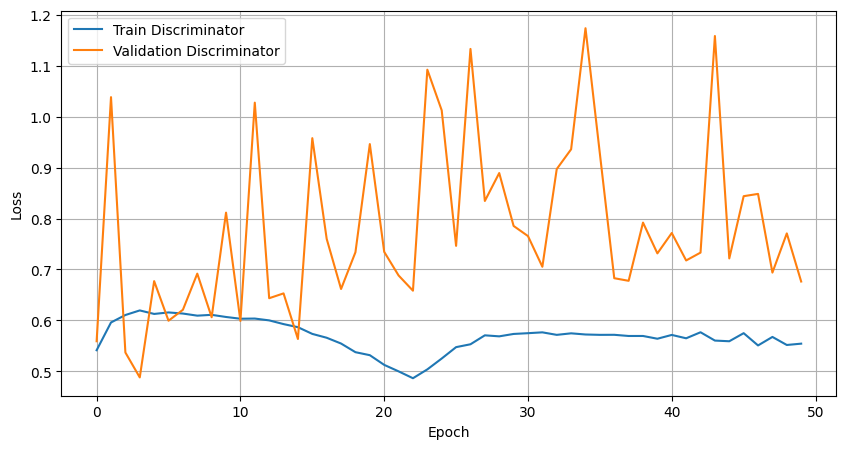

In [61]:
# ============================================================
# 修正: 学習曲線プロット（history辞書ベース）
# ============================================================
plt.figure(figsize=(10, 5))
plt.plot(history["train_g"], label="Train Generator")
plt.plot(history["val_g"], label="Validation Generator")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid()
plt.savefig("/kaggle/working/loss_curve_g.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history["train_d"], label="Train Discriminator")
plt.plot(history["val_d"], label="Validation Discriminator")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid()
plt.savefig("/kaggle/working/loss_curve_d.png", dpi=150)
plt.show()

In [63]:
torch.save(
    generator.state_dict(),
    "/kaggle/working/pix2pix_generator.pth"
)

torch.save(
    discriminator.state_dict(),
    "/kaggle/working/pix2pix_discriminator.pth"
)

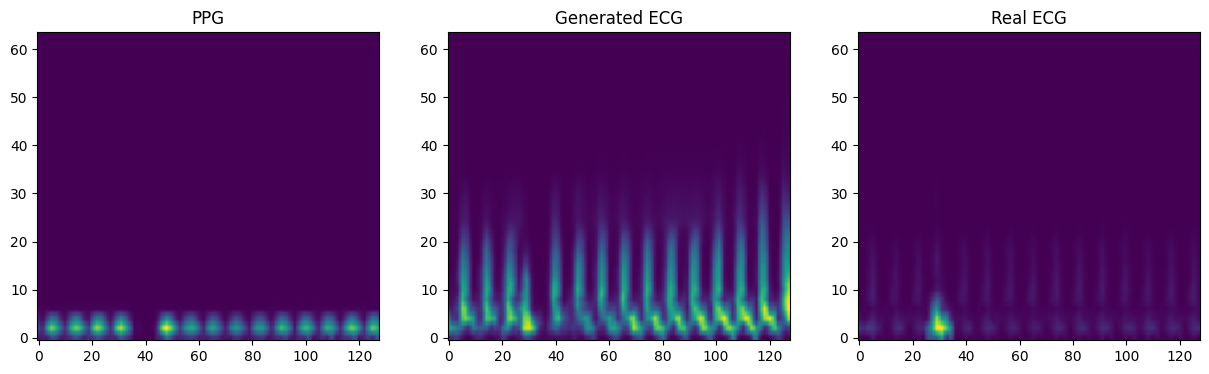

In [64]:
generator.eval()

ppg, real_ecg = next(iter(val_loader))

ppg = ppg.to(device)
real_ecg = real_ecg.to(device)

with torch.no_grad():
    fake_ecg = generator(ppg)

sample = 0

fig, ax = plt.subplots(
    1,
    3,
    figsize=(15,4)
)

ax[0].imshow(
    ppg[sample,0].cpu(),
    aspect="auto",
    origin="lower"
)
ax[0].set_title("PPG")

ax[1].imshow(
    fake_ecg[sample,0].cpu(),
    aspect="auto",
    origin="lower"
)
ax[1].set_title("Generated ECG")

ax[2].imshow(
    real_ecg[sample,0].cpu(),
    aspect="auto",
    origin="lower"
)
ax[2].set_title("Real ECG")

plt.show()

In [65]:
# ============================================================
# 修正: 定量評価（data_range統一版。旧Cell31/38/39を統合）
# ============================================================
from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim
from scipy.stats import pearsonr

DATA_RANGE = 2.0  # データは[-1,1]なので必ず2.0を使用

# ── 評価対象チェックポイントを明示的に指定（変数名の取り違え事故を防止） ──
EVAL_CHECKPOINT_PATH = "/kaggle/working/best_generator.pth"  # ← 評価したいモデルのパスをここで都度指定
generator = UNetGenerator().to(device)
generator.load_state_dict(torch.load(EVAL_CHECKPOINT_PATH, map_location=device))
generator.eval()
print(f"評価対象: {EVAL_CHECKPOINT_PATH}")

mse_list, ssim_list, corr_list = [], [], []
x_test, y_test, pred_test = [], [], []

with torch.no_grad():
    for ppg, real_ecg in val_loader:
        ppg, real_ecg = ppg.to(device), real_ecg.to(device)
        fake_ecg = generator(ppg)

        x_test.append(ppg.cpu().numpy())
        y_test.append(real_ecg.cpu().numpy())
        pred_test.append(fake_ecg.cpu().numpy())

        for i in range(fake_ecg.shape[0]):
            gt = real_ecg[i,0].cpu().numpy()
            pred = fake_ecg[i,0].cpu().numpy()
            mse_list.append(mean_squared_error(gt.flatten(), pred.flatten()))
            ssim_list.append(ssim(gt, pred, data_range=DATA_RANGE))
            corr, _ = pearsonr(gt.flatten(), pred.flatten())
            corr_list.append(corr)

x_test = np.concatenate(x_test, axis=0)
y_test = np.concatenate(y_test, axis=0)
pred_test = np.concatenate(pred_test, axis=0)

print(f"MSE : {np.mean(mse_list):.4f} ± {np.std(mse_list):.4f}")
print(f"SSIM: {np.mean(ssim_list):.4f} ± {np.std(ssim_list):.4f}")
print(f"Corr: {np.mean(corr_list):.4f} ± {np.std(corr_list):.4f}")

評価対象: /kaggle/working/best_generator.pth
MSE : 0.0342 ± 0.0169
SSIM: 0.8404 ± 0.0796
Corr: 0.7372 ± 0.1709


In [29]:
# ============================================================
# 新規セル: Step5 — Griffin-Lim波形復元 + R-peak/RR間隔評価
# ============================================================
import librosa

def get_stft_freq_time_bins(seg_len=SEG_LEN, fs=FS, nperseg=NPERSEG, noverlap=NOVERLAP):
    dummy = np.zeros(seg_len)
    f, t, _ = scipy_spectrogram(dummy, fs=fs, nperseg=nperseg, noverlap=noverlap,
                                 window='hann', scaling='spectrum')
    return len(f), len(t)

ORIG_H, ORIG_W = get_stft_freq_time_bins()

def denormalize_spectrogram(spec_resized, log_min, log_max, orig_h=ORIG_H, orig_w=ORIG_W):
    """[-1,1]画像→元のSTFT振幅スケールへの近似逆変換（zoomの非可逆性に留意）"""
    spec01 = np.clip((spec_resized + 1.0) / 2.0, 0.0, 1.0)
    zh, zw = orig_h / spec01.shape[0], orig_w / spec01.shape[1]
    spec_orig = zoom(spec01, (zh, zw), order=1)
    log_mag = spec_orig * (log_max - log_min) + log_min
    return np.maximum(np.expm1(log_mag), 0.0).astype(np.float32)

def spectrogram_to_waveform(mag_spec, fs=FS, nperseg=NPERSEG, noverlap=NOVERLAP, n_iter=32):
    hop = nperseg - noverlap
    amp_spec = np.sqrt(np.maximum(mag_spec, 0.0))  # power(scaling='spectrum') → 振幅に変換
    return librosa.griffinlim(
        amp_spec, n_iter=n_iter, hop_length=hop, win_length=nperseg,
        n_fft=nperseg, window='hann', center=False, length=SEG_LEN
    )

def evaluate_time_domain(real_wave, fake_wave, fs=FS):
    result = {"n_rpeaks_real": np.nan, "n_rpeaks_fake": np.nan,
              "rpeak_count_diff": np.nan, "rr_mean_diff_ms": np.nan}
    try:
        _, ri = nk.ecg_peaks(real_wave, sampling_rate=fs)
        _, fi = nk.ecg_peaks(fake_wave, sampling_rate=fs)
        rp, fp = ri["ECG_R_Peaks"], fi["ECG_R_Peaks"]
        result["n_rpeaks_real"], result["n_rpeaks_fake"] = len(rp), len(fp)
        result["rpeak_count_diff"] = len(fp) - len(rp)
        if len(rp) > 1 and len(fp) > 1:
            rr_r = np.diff(rp) / fs * 1000
            rr_f = np.diff(fp) / fs * 1000
            result["rr_mean_diff_ms"] = abs(rr_r.mean() - rr_f.mean())
    except Exception as e:
        result["error"] = str(e)
    return result

# ── val全体で評価（real/fake両方を同一Griffin-Lim経路で復元し、
#     GAN由来の誤差とSTFT round-trip誤差を分離する） ──
val_npz_v3 = np.load("/kaggle/working/bidmc_val_v3.npz")
ecg_log_min_val = val_npz_v3["ecg_log_min"]
ecg_log_max_val = val_npz_v3["ecg_log_max"]

time_domain_results = []
generator.eval()
with torch.no_grad():
    for i in range(len(val_dataset)):
        ppg_t = val_dataset[i][0].unsqueeze(0).to(device)
        fake_spec = generator(ppg_t)[0,0].cpu().numpy()
        real_spec = val_dataset[i][1][0].numpy()

        log_min, log_max = ecg_log_min_val[i], ecg_log_max_val[i]
        real_mag = denormalize_spectrogram(real_spec, log_min, log_max)
        fake_mag = denormalize_spectrogram(fake_spec, log_min, log_max)

        real_wave = spectrogram_to_waveform(real_mag)
        fake_wave = spectrogram_to_waveform(fake_mag)

        res = evaluate_time_domain(real_wave, fake_wave)
        res["idx"] = i
        time_domain_results.append(res)

td_df = pd.DataFrame(time_domain_results)
print(td_df[["rpeak_count_diff", "rr_mean_diff_ms"]].describe())
print(f"\nR波検出数差の平均絶対値: {td_df['rpeak_count_diff'].abs().mean():.2f} 拍/10秒窓")
print(f"RR間隔平均誤差: {td_df['rr_mean_diff_ms'].mean():.1f} ms")

       rpeak_count_diff  rr_mean_diff_ms
count        950.000000       950.000000
mean          -0.070526        21.094429
std            0.867560        54.299202
min           -7.000000         0.000000
25%            0.000000         1.846154
50%            0.000000         4.000000
75%            0.000000         8.000000
max            3.000000       648.923077

R波検出数差の平均絶対値: 0.39 拍/10秒窓
RR間隔平均誤差: 21.1 ms


In [41]:
# ============================================================
# 新規セル: RR間隔誤差の裾（>100ms）とCorr<0.4群の重複確認
# ============================================================
rr_bad_idx = td_df[td_df["rr_mean_diff_ms"] > 100]["idx"].values
corr_bad_idx = np.where(np.array(corr_list) < 0.4)[0]  # ※このセル実行時点でcorr_listが定義済みである必要あり

overlap = set(rr_bad_idx) & set(corr_bad_idx)

print(f"RR誤差>100msのセグメント数: {len(rr_bad_idx)}")
print(f"Corr<0.4のセグメント数    : {len(corr_bad_idx)}")
print(f"両者の重複数              : {len(overlap)} "
      f"({100*len(overlap)/max(len(rr_bad_idx),1):.1f}% がRR誤差>100msのうち)")

if len(overlap) > 0:
    print("\n重複セグメントの被験者内訳:")
    if "test_subject_ids" not in globals():
        test_subject_ids = np.load("/kaggle/working/bidmc_val_v3.npz")["sid"]
    overlap_subjects = test_subject_ids[list(overlap)]
    for sid in np.unique(overlap_subjects):
        print(f"  Subject {sid}: {np.sum(overlap_subjects==sid)}件")

RR誤差>100msのセグメント数: 50
Corr<0.4のセグメント数    : 68
両者の重複数              : 16 (32.0% がRR誤差>100msのうち)

重複セグメントの被験者内訳:
  Subject 4: 1件
  Subject 33: 13件
  Subject 44: 2件


In [42]:
# ============================================================
# 新規セル: エネルギーマスクCorr（背景バイアスの影響を定量化）
# ============================================================
def energy_masked_corr(real, fake, top_pct=0.2):
    threshold = np.percentile(real, 100 * (1 - top_pct))
    mask = real >= threshold
    if mask.sum() < 2:
        return np.nan
    return np.corrcoef(real[mask], fake[mask])[0, 1]

masked_corr_list = [
    energy_masked_corr(y_test[i,0], pred_test[i,0])
    for i in range(len(y_test))
]

print(f"全ピクセルCorr     : {np.mean(corr_list):.4f} ± {np.std(corr_list):.4f}")
print(f"エネルギー上位20%Corr: {np.nanmean(masked_corr_list):.4f} ± {np.nanstd(masked_corr_list):.4f}")
print(f"差分（背景バイアスの目安）: {np.mean(corr_list) - np.nanmean(masked_corr_list):.4f}")

全ピクセルCorr     : 0.7458 ± 0.1838
エネルギー上位20%Corr: 0.5194 ± 0.2716
差分（背景バイアスの目安）: 0.2264


In [43]:
# ============================================================
# 新規セル: 指標サマリー（エネルギーマスクCorrを主指標として明示）
# ============================================================
print("=" * 50)
print("最終報告用サマリー（主指標を明示）")
print("=" * 50)
print(f"[主指標] エネルギー上位20%Corr: {np.nanmean(masked_corr_list):.4f} ± {np.nanstd(masked_corr_list):.4f}")
print(f"[参考値] 全ピクセルCorr        : {np.mean(corr_list):.4f} ± {np.std(corr_list):.4f}")
print(f"[参考値] SSIM                  : {np.mean(ssim_list):.4f} ± {np.std(ssim_list):.4f}")
print(f"[参考値] MSE                   : {np.mean(mse_list):.4f} ± {np.std(mse_list):.4f}")
print(f"[時間領域] RR間隔誤差中央値     : {td_df['rr_mean_diff_ms'].median():.1f} ms")
print(f"[時間領域] RR間隔誤差平均       : {td_df['rr_mean_diff_ms'].mean():.1f} ms（裾の影響で平均は過大）")

最終報告用サマリー（主指標を明示）
[主指標] エネルギー上位20%Corr: 0.5194 ± 0.2716
[参考値] 全ピクセルCorr        : 0.7458 ± 0.1838
[参考値] SSIM                  : 0.8497 ± 0.0862
[参考値] MSE                   : 0.0360 ± 0.0220
[時間領域] RR間隔誤差中央値     : 4.0 ms
[時間領域] RR間隔誤差平均       : 21.1 ms（裾の影響で平均は過大）


In [44]:
# ============================================================
# 修正: Step2 — Worst症例の診断（PPG側品質指標を追加）
# ============================================================
val_npz = np.load("/kaggle/working/bidmc_val_v3.npz")
test_subject_ids = val_npz["sid"]
ecg_clip_val = val_npz["ecg_clip_ratio"]
n_rpeaks_val = val_npz["n_rpeaks_raw"]
ppg_clip_val = val_npz["ppg_clip_ratio"]
ppg_pulse_presence_val = val_npz["ppg_pulse_presence"]  # ← 追加

# PPGスペクトログラム画像のエネルギー（低灌流/体動アーティファクトの代理指標）
ppg_energy = np.array([x_test[i, 0].std() for i in range(len(x_test))])
ppg_energy_p10 = np.percentile(ppg_energy, 10)  # 下位10%を低エネルギーと判定

worst_idx = np.argsort(corr_list)[:10]

print(f"{'idx':>5} {'subject':>8} {'corr':>7} {'ecg_clip':>9} {'ppg_clip':>9} "
      f"{'n_rpeaks':>9} {'ppg_energy':>11} {'pulse_pres':>10} {'判定':>12}")
for idx in worst_idx:
    ecg_clip = ecg_clip_val[idx]
    ppg_clip = ppg_clip_val[idx]
    nrp = n_rpeaks_val[idx]
    ppg_e = ppg_energy[idx]
    pulse_presence = ppg_pulse_presence_val[idx]

    if ecg_clip > 0.05:
        judge = "ECGクリップ"
    elif ppg_clip > 0.05:
        judge = "PPGクリップ"
    elif ppg_e < ppg_energy_p10:
        judge = "PPG低エネルギー"
    elif pulse_presence < 0.4:
        judge = "PPGパルス断続"
    elif nrp == -1 or nrp < 6 or nrp > 22:
        judge = "R波数異常"
    else:
        judge = "原因不明"

    print(f"{idx:>5} {test_subject_ids[idx]:>8} {corr_list[idx]:>7.3f} "
          f"{ecg_clip:>9.3f} {ppg_clip:>9.3f} {nrp:>9} {ppg_e:>11.4f} {pulse_presence:>10.3f} {judge:>12}")

  idx  subject    corr  ecg_clip  ppg_clip  n_rpeaks  ppg_energy pulse_pres           判定
  722       44   0.194     0.001     0.036        15      0.1104      0.000    PPG低エネルギー
  529       33   0.230     0.025     0.009        12      0.1451      0.000    PPG低エネルギー
  542       33   0.237     0.026     0.005        12      0.1460      0.000    PPG低エネルギー
  507       33   0.248     0.018     0.010        14      0.1442      0.000    PPG低エネルギー
  528       33   0.255     0.012     0.009        13      0.1430      0.000    PPG低エネルギー
  477       33   0.268     0.018     0.009        13      0.1687      0.000     PPGパルス断続
  499       33   0.270     0.018     0.005        13      0.1514      0.000     PPGパルス断続
  475       33   0.271     0.026     0.008        11      0.1425      0.000    PPG低エネルギー
  512       33   0.272     0.030     0.005        14      0.1317      0.000    PPG低エネルギー
  497       33   0.286     0.024     0.006        14      0.1492      0.000     PPGパルス断続


In [51]:
# ============================================================
# 新規セル: A群（高振幅・クリーン）/ B群（体動疑い）でのCorr比較
# ============================================================
group_a = [47, 53, 42, 45]           # 高振幅だが規則的（クリーン）
group_b = [44, 48, 40, 46, 52]       # 体動アーティファクト/低灌流疑い

for label, group in [("A群(高振幅・クリーン)", group_a), ("B群(体動疑い)", group_b)]:
    corrs = [c for sid, c in zip(test_subject_ids, corr_list) if sid in group]
    included = sorted(set(sid for sid in test_subject_ids if sid in group))
    if corrs:
        print(f"{label}: n_segments={len(corrs)}, "
              f"該当被験者(val内)={included}, "
              f"Corr={np.mean(corrs):.3f} ± {np.std(corrs):.3f}")
    else:
        print(f"{label}: val setに該当被験者なし（該当被験者は全員train側の可能性）")

# 参考: それ以外（A群・B群のどちらにも属さない被験者）との比較
other_corrs = [c for sid, c in zip(test_subject_ids, corr_list)
               if sid not in group_a and sid not in group_b]
print(f"\nその他被験者: n_segments={len(other_corrs)}, "
      f"Corr={np.mean(other_corrs):.3f} ± {np.std(other_corrs):.3f}")

# ── 5.1のenv_instab指標との整合性確認（5.1適用後のみ実行可） ──
if "ppg_env_instab" in val_npz.files:
    env_instab_val = val_npz["ppg_env_instab"]
    for label, group in [("A群", group_a), ("B群", group_b), ("その他", None)]:
        if group is None:
            mask = np.array([sid not in group_a and sid not in group_b for sid in test_subject_ids])
        else:
            mask = np.array([sid in group for sid in test_subject_ids])
        if mask.sum() > 0:
            print(f"{label}: env_instab平均={env_instab_val[mask].mean():.3f} "
                  f"(n={mask.sum()})")

A群(高振幅・クリーン): n_segments=95, 該当被験者(val内)=[np.int64(42)], Corr=0.885 ± 0.020
B群(体動疑い): n_segments=190, 該当被験者(val内)=[np.int64(44), np.int64(48)], Corr=0.793 ± 0.102

その他被験者: n_segments=665, Corr=0.712 ± 0.202
A群: env_instab平均=0.029 (n=95)
B群: env_instab平均=0.038 (n=190)
その他: env_instab平均=0.038 (n=665)


In [ ]:
# ============================================================
# 新規セル（検証用・一時的）: pulse_presence_ratio修正版の分布確認
# ============================================================
sample_subjects = [33, 51, 44, 42]  # Worst被験者・Best被験者・B群・A群を1件ずつ
for sid in sample_subjects:
    df = load_signals(sid)
    ppg_full = df[PPG_COL].values[:SEG_LEN].astype(np.float32)
    ppg_f = bandpass_filter(ppg_full, FS, 0.5, 4.0)
    ppg_n = normalize_zscore(ppg_f)
    pr = pulse_presence_ratio(ppg_n)
    print(f"Subject {sid}: pulse_presence(修正版) = {pr:.3f}")

In [52]:
# ============================================================
# 新規セル: train側のB群被験者に対する推論確認（40,46,52）
# ============================================================
train_npz = np.load("/kaggle/working/bidmc_train_v3.npz")
train_sid = train_npz["sid"]
train_ppg = train_npz["ppg"].astype(np.float32)
train_ecg = train_npz["ecg"].astype(np.float32)

b_group_in_train = [40, 46, 52]
mask = np.isin(train_sid, b_group_in_train)
print(f"train側のB群セグメント数: {mask.sum()}")

generator.eval()
b_train_corrs = []
with torch.no_grad():
    idxs = np.where(mask)[0]
    for i in idxs:
        ppg_t = torch.from_numpy(train_ppg[i]).unsqueeze(0).unsqueeze(0).to(device) * 2 - 1
        real_t = train_ecg[i]
        fake = generator(ppg_t)[0,0].cpu().numpy()
        c, _ = pearsonr(((real_t*2-1)).flatten(), fake.flatten())
        b_train_corrs.append(c)

print(f"train側B群(40,46,52) Corr: {np.mean(b_train_corrs):.3f} ± {np.std(b_train_corrs):.3f}")
print("※ これは訓練データそのものなので汎化性能の指標にはならない点に注意。"
      "あくまで「学習中にこの被験者データをどの程度捉えられているか」の参考値。")

train側のB群セグメント数: 285
train側B群(40,46,52) Corr: 0.905 ± 0.104
※ これは訓練データそのものなので汎化性能の指標にはならない点に注意。あくまで「学習中にこの被験者データをどの程度捉えられているか」の参考値。


In [53]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/working/generator_final.pth
/kaggle/working/bidmc_train_v3.npz
/kaggle/working/pix2pix_discriminator.pth
/kaggle/working/loss_curve_g.png
/kaggle/working/bidmc_train_v2.npz
/kaggle/working/discriminator_final.pth
/kaggle/working/best_generator.pth
/kaggle/working/bidmc_val_v2.npz
/kaggle/working/bidmc_spectrograms.npz
/kaggle/working/signal_check_s01.png
/kaggle/working/loss_curve_d.png
/kaggle/working/gen_lambda50_screen.pth
/kaggle/working/spec_check_s01_seg0.png
/kaggle/working/bidmc_val_v3.npz
/kaggle/working/pix2pix_generator.pth
/kaggle/working/.virtual_documents/__notebook_source__.ipynb
/kaggle/working/inference/sample_28.png
/kaggle/working/inference/sample_21.png
/kaggle/working/inference/sample_22.png
/kaggle/working/inference/sample_15.png
/kaggle/working/inference/sample_06.png
/kaggle/working/inference/sample_02.png
/kaggle/working/inference/sample_14.png
/kaggle/working/inference/sample_16.png
/kaggle/working/inference/sample_29.png
/kaggle/working/inference/samp

In [54]:
torch.save(
    generator.state_dict(),
    "/kaggle/working/generator_final.pth"
)

torch.save(
    discriminator.state_dict(),
    "/kaggle/working/discriminator_final.pth"
)

print("Model saved.")

Model saved.


In [57]:
generator.eval()

save_dir = "/kaggle/working/inference"
os.makedirs(save_dir, exist_ok=True)

In [58]:
with torch.no_grad():

    for i in range(30):

        ppg = val_dataset[i][0].unsqueeze(0).to(device)
        real = val_dataset[i][1].unsqueeze(0).to(device)

        fake = generator(ppg)

        fig, ax = plt.subplots(
            1,
            3,
            figsize=(12,4)
        )

        ax[0].imshow(
            ppg[0,0].cpu(),
            origin="lower",
            aspect="auto",
            cmap="inferno"
        )
        ax[0].set_title("PPG")

        ax[1].imshow(
            real[0,0].cpu(),
            origin="lower",
            aspect="auto",
            cmap="inferno"
        )
        ax[1].set_title("Real ECG")

        ax[2].imshow(
            fake[0,0].cpu(),
            origin="lower",
            aspect="auto",
            cmap="inferno"
        )
        ax[2].set_title("Generated ECG")

        plt.tight_layout()

        plt.savefig(
            f"{save_dir}/sample_{i:02d}.png"
        )

        plt.close()

In [59]:
from skimage.metrics import structural_similarity as ssim

print(type(ssim))

<class 'function'>


In [60]:
print("MSE")
print(
    np.mean(mse_list),
    "±",
    np.std(mse_list)
)

print("SSIM")
print(
    np.mean(ssim_list),
    "±",
    np.std(ssim_list)
)

print("Corr")
print(
    np.mean(corr_list),
    "±",
    np.std(corr_list)
)

MSE
0.035986754346246784 ± 0.021967873514265546
SSIM
0.8496593244646968 ± 0.08623908926391301
Corr
0.7457541 ± 0.18381609


In [61]:
x_test = []
y_test = []
pred_test = []

generator.eval()

with torch.no_grad():

    for ppg, real_ecg in val_loader:

        ppg = ppg.to(device)
        real_ecg = real_ecg.to(device)

        fake_ecg = generator(ppg)

        x_test.append(
            ppg.cpu().numpy()
        )

        y_test.append(
            real_ecg.cpu().numpy()
        )

        pred_test.append(
            fake_ecg.cpu().numpy()
        )

x_test = np.concatenate(x_test, axis=0)
y_test = np.concatenate(y_test, axis=0)
pred_test = np.concatenate(pred_test, axis=0)

print(x_test.shape)
print(y_test.shape)
print(pred_test.shape)
print("test_subject_ids" in globals())

(950, 1, 64, 128)
(950, 1, 64, 128)
(950, 1, 64, 128)
True


In [62]:
corr_arr = np.array(corr_list)

worst_idx = np.argsort(corr_arr)[:10]

print(worst_idx)
print(corr_arr[worst_idx])

[722 529 542 507 528 477 499 475 512 497]
[0.19378302 0.22957233 0.23739895 0.24825451 0.25522277 0.26813728
 0.2697678  0.27124563 0.27175468 0.28583792]


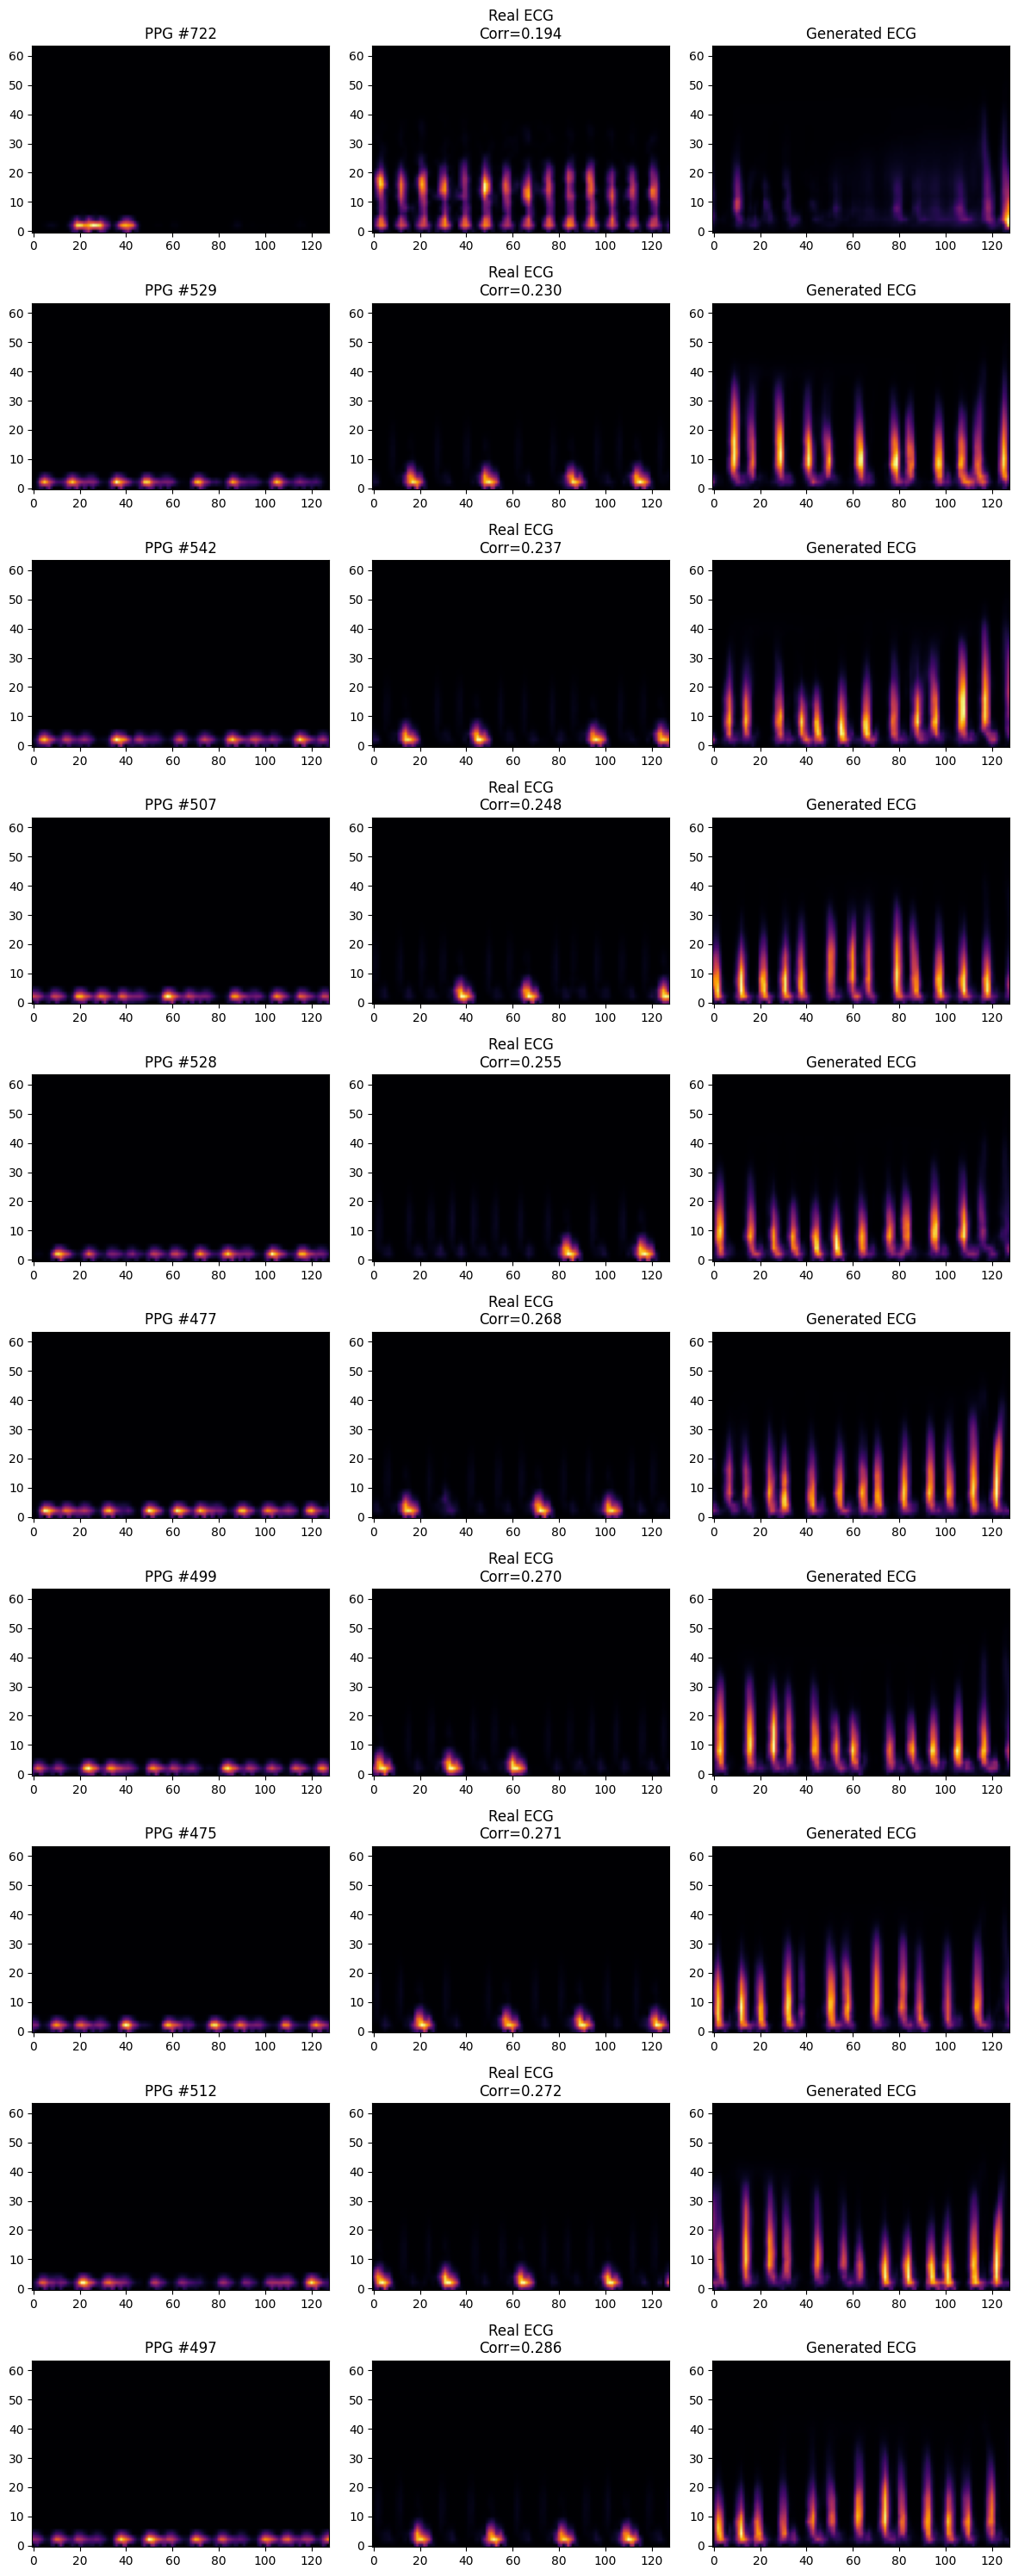

In [63]:
worst_idx = np.argsort(corr_list)[:10]

fig, axes = plt.subplots(
    len(worst_idx),
    3,
    figsize=(12, 3*len(worst_idx))
)

for i, idx in enumerate(worst_idx):

    ppg = x_test[idx,0]
    real = y_test[idx,0]
    fake = pred_test[idx,0]

    axes[i,0].imshow(
        ppg,
        aspect='auto',
        origin='lower',
        cmap='inferno'
    )
    axes[i,0].set_title(f"PPG #{idx}")

    axes[i,1].imshow(
        real,
        aspect='auto',
        origin='lower',
        cmap='inferno'
    )
    axes[i,1].set_title(
        f"Real ECG\nCorr={corr_list[idx]:.3f}"
    )

    axes[i,2].imshow(
        fake,
        aspect='auto',
        origin='lower',
        cmap='inferno'
    )
    axes[i,2].set_title("Generated ECG")

plt.tight_layout()
plt.show()

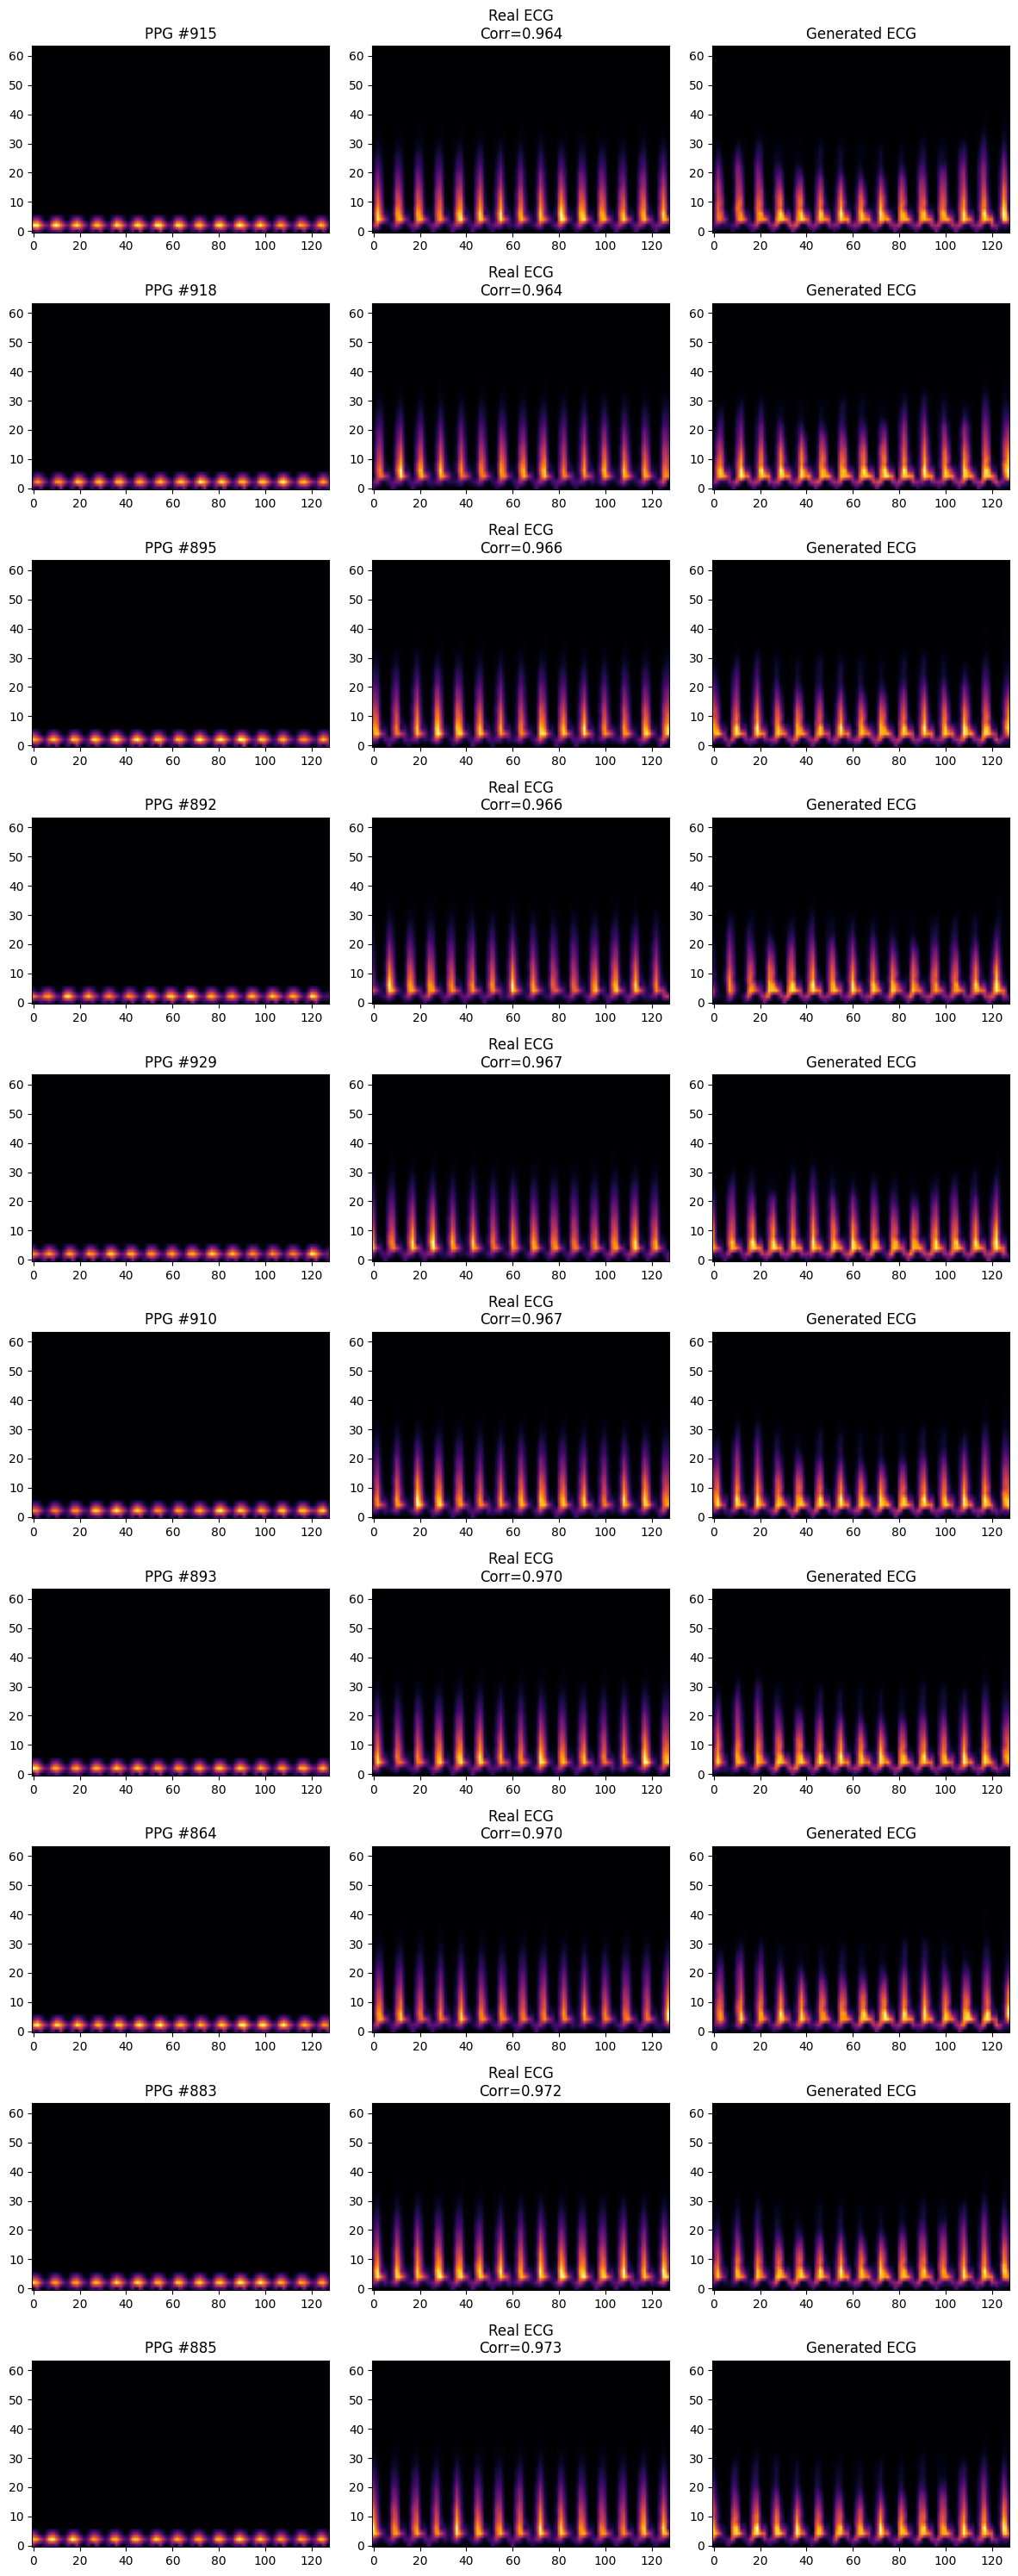

In [64]:
best_idx = np.argsort(corr_list)[-10:]

fig, axes = plt.subplots(
    len(best_idx),
    3,
    figsize=(12, 3*len(best_idx))
)

for i, idx in enumerate(best_idx):

    ppg = x_test[idx,0]
    real = y_test[idx,0]
    fake = pred_test[idx,0]

    axes[i,0].imshow(
        ppg,
        aspect='auto',
        origin='lower',
        cmap='inferno'
    )
    axes[i,0].set_title(f"PPG #{idx}")

    axes[i,1].imshow(
        real,
        aspect='auto',
        origin='lower',
        cmap='inferno'
    )
    axes[i,1].set_title(
        f"Real ECG\nCorr={corr_list[idx]:.3f}"
    )

    axes[i,2].imshow(
        fake,
        aspect='auto',
        origin='lower',
        cmap='inferno'
    )
    axes[i,2].set_title("Generated ECG")

plt.tight_layout()
plt.show()

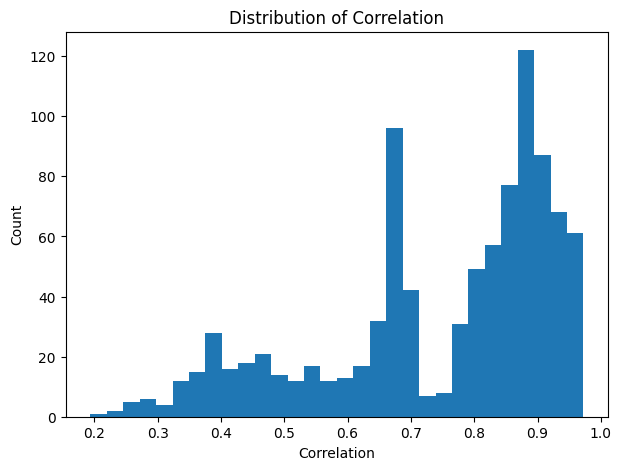

In [65]:
plt.figure(figsize=(7,5))

plt.hist(
    corr_list,
    bins=30
)

plt.xlabel("Correlation")
plt.ylabel("Count")
plt.title("Distribution of Correlation")

plt.show()

In [66]:
val_npz = np.load(
    "/kaggle/working/bidmc_val_v3.npz"
)

test_subject_ids = val_npz["sid"]

In [67]:
subject_corr = {}

for sid, c in zip(test_subject_ids, corr_list):

    if sid not in subject_corr:
        subject_corr[sid] = []

    subject_corr[sid].append(c)

for sid in sorted(subject_corr):

    arr = np.array(subject_corr[sid])

    print(
        f"Subject {sid:02d} : "
        f"{arr.mean():.3f} ± {arr.std():.3f}"
    )

Subject 04 : 0.619 ± 0.140
Subject 06 : 0.678 ± 0.013
Subject 13 : 0.568 ± 0.075
Subject 18 : 0.918 ± 0.021
Subject 20 : 0.872 ± 0.031
Subject 33 : 0.393 ± 0.074
Subject 42 : 0.885 ± 0.020
Subject 44 : 0.780 ± 0.117
Subject 48 : 0.806 ± 0.084
Subject 51 : 0.938 ± 0.033


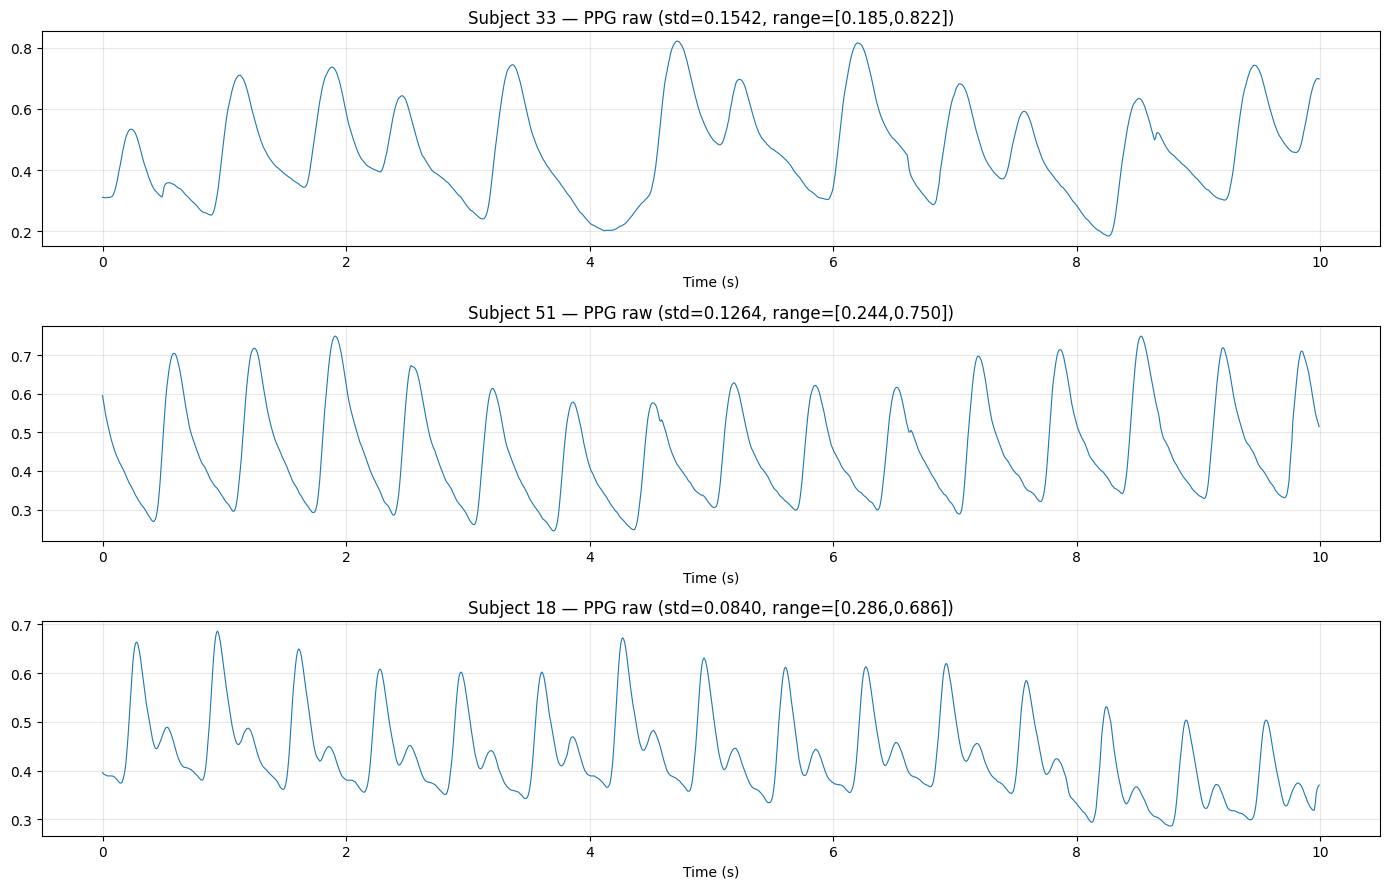

 subject      std    range
      19 0.038214 0.347990
       1 0.065512 0.474100
      22 0.071147 0.524920
      32 0.072679 0.910071
      41 0.074333 0.830890
      25 0.074504 0.956990
      24 0.082136 0.457480
      50 0.082630 1.000000
      12 0.085737 0.680350
      20 0.087422 1.000000
      21 0.090060 1.000000
      18 0.094077 0.612900
      38 0.094380 0.903230
       5 0.096824 1.000000
      26 0.098716 1.000000
      31 0.103031 0.920821
      11 0.105645 0.809380
      13 0.117666 0.983380
      28 0.120340 0.834800
       9 0.128753 0.471160
      37 0.144129 1.000000
      39 0.144567 0.786898
      16 0.144806 0.913000
      33 0.146525 0.941349
      51 0.147182 0.601170
      30 0.147995 0.998040
      34 0.149133 1.000000
       3 0.149820 0.714570
       2 0.150118 0.825030
      15 0.150908 0.885630
      49 0.151495 1.000000
      17 0.153241 0.967740
       4 0.153376 0.976540
      43 0.154386 0.918866
       7 0.155811 0.561090
       6 0.156086 0.736074
 

In [68]:
# ============================================================
# 新規セル: Subject33のPPG生波形を他被験者と比較
# ============================================================
compare_subjects = [33, 51, 18]  # 最悪(33)・最良(51)・良好(18)

fig, axes = plt.subplots(len(compare_subjects), 1, figsize=(14, 3*len(compare_subjects)))

for ax, sid in zip(axes, compare_subjects):
    df = load_signals(sid)
    ppg_raw = df[PPG_COL].values[:SEG_LEN].astype(np.float32)
    t = np.arange(SEG_LEN) / FS

    ax.plot(t, ppg_raw, linewidth=0.8)
    ax.set_title(f"Subject {sid} — PPG raw (std={ppg_raw.std():.4f}, "
                 f"range=[{ppg_raw.min():.3f},{ppg_raw.max():.3f}])")
    ax.set_xlabel("Time (s)")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/subject33_ppg_comparison.png", dpi=150)
plt.show()

# 全被験者のPPG振幅統計を一覧化（Subject33が外れ値かを定量確認）
ppg_stats = []
for sid in subject_ids:
    df = load_signals(sid)
    ppg_raw = df[PPG_COL].values.astype(np.float32)
    ppg_stats.append({"subject": sid, "std": ppg_raw.std(),
                       "range": ppg_raw.max() - ppg_raw.min()})

ppg_stats_df = pd.DataFrame(ppg_stats).sort_values("std")
print(ppg_stats_df.to_string(index=False))
print(f"\nSubject33の順位: {(ppg_stats_df['subject']==33).idxmax()+1} / {len(ppg_stats_df)} (std昇順)")

/tmp/ipykernel_58/1155797339.py:15: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/1155797339.py:15: UserWarning: Glyph 35352 (\N{CJK UNIFIED IDEOGRAPH-8A18}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/1155797339.py:15: UserWarning: Glyph 37682 (\N{CJK UNIFIED IDEOGRAPH-9332}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/1155797339.py:16: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) DejaVu Sans.
  plt.savefig("/kaggle/working/anomaly_subjects_full_waveform.png", dpi=100)
/tmp/ipykernel_58/1155797339.py:16: UserWarning: Glyph 35352 (\N{CJK UNIFIED IDEOGRAPH-8A18}) missing from font(s) DejaVu Sans.
  plt.savefig("/kaggle/working/anomaly_subjects_full_waveform.png", dpi=100)
/tmp/ipykernel_58/1155797339.py:16: UserWarning: Glyph 37682 (\N{CJK UNIFIED IDEOGRAPH-9332}) missing from font(s) DejaVu Sans.
  plt.savefig("

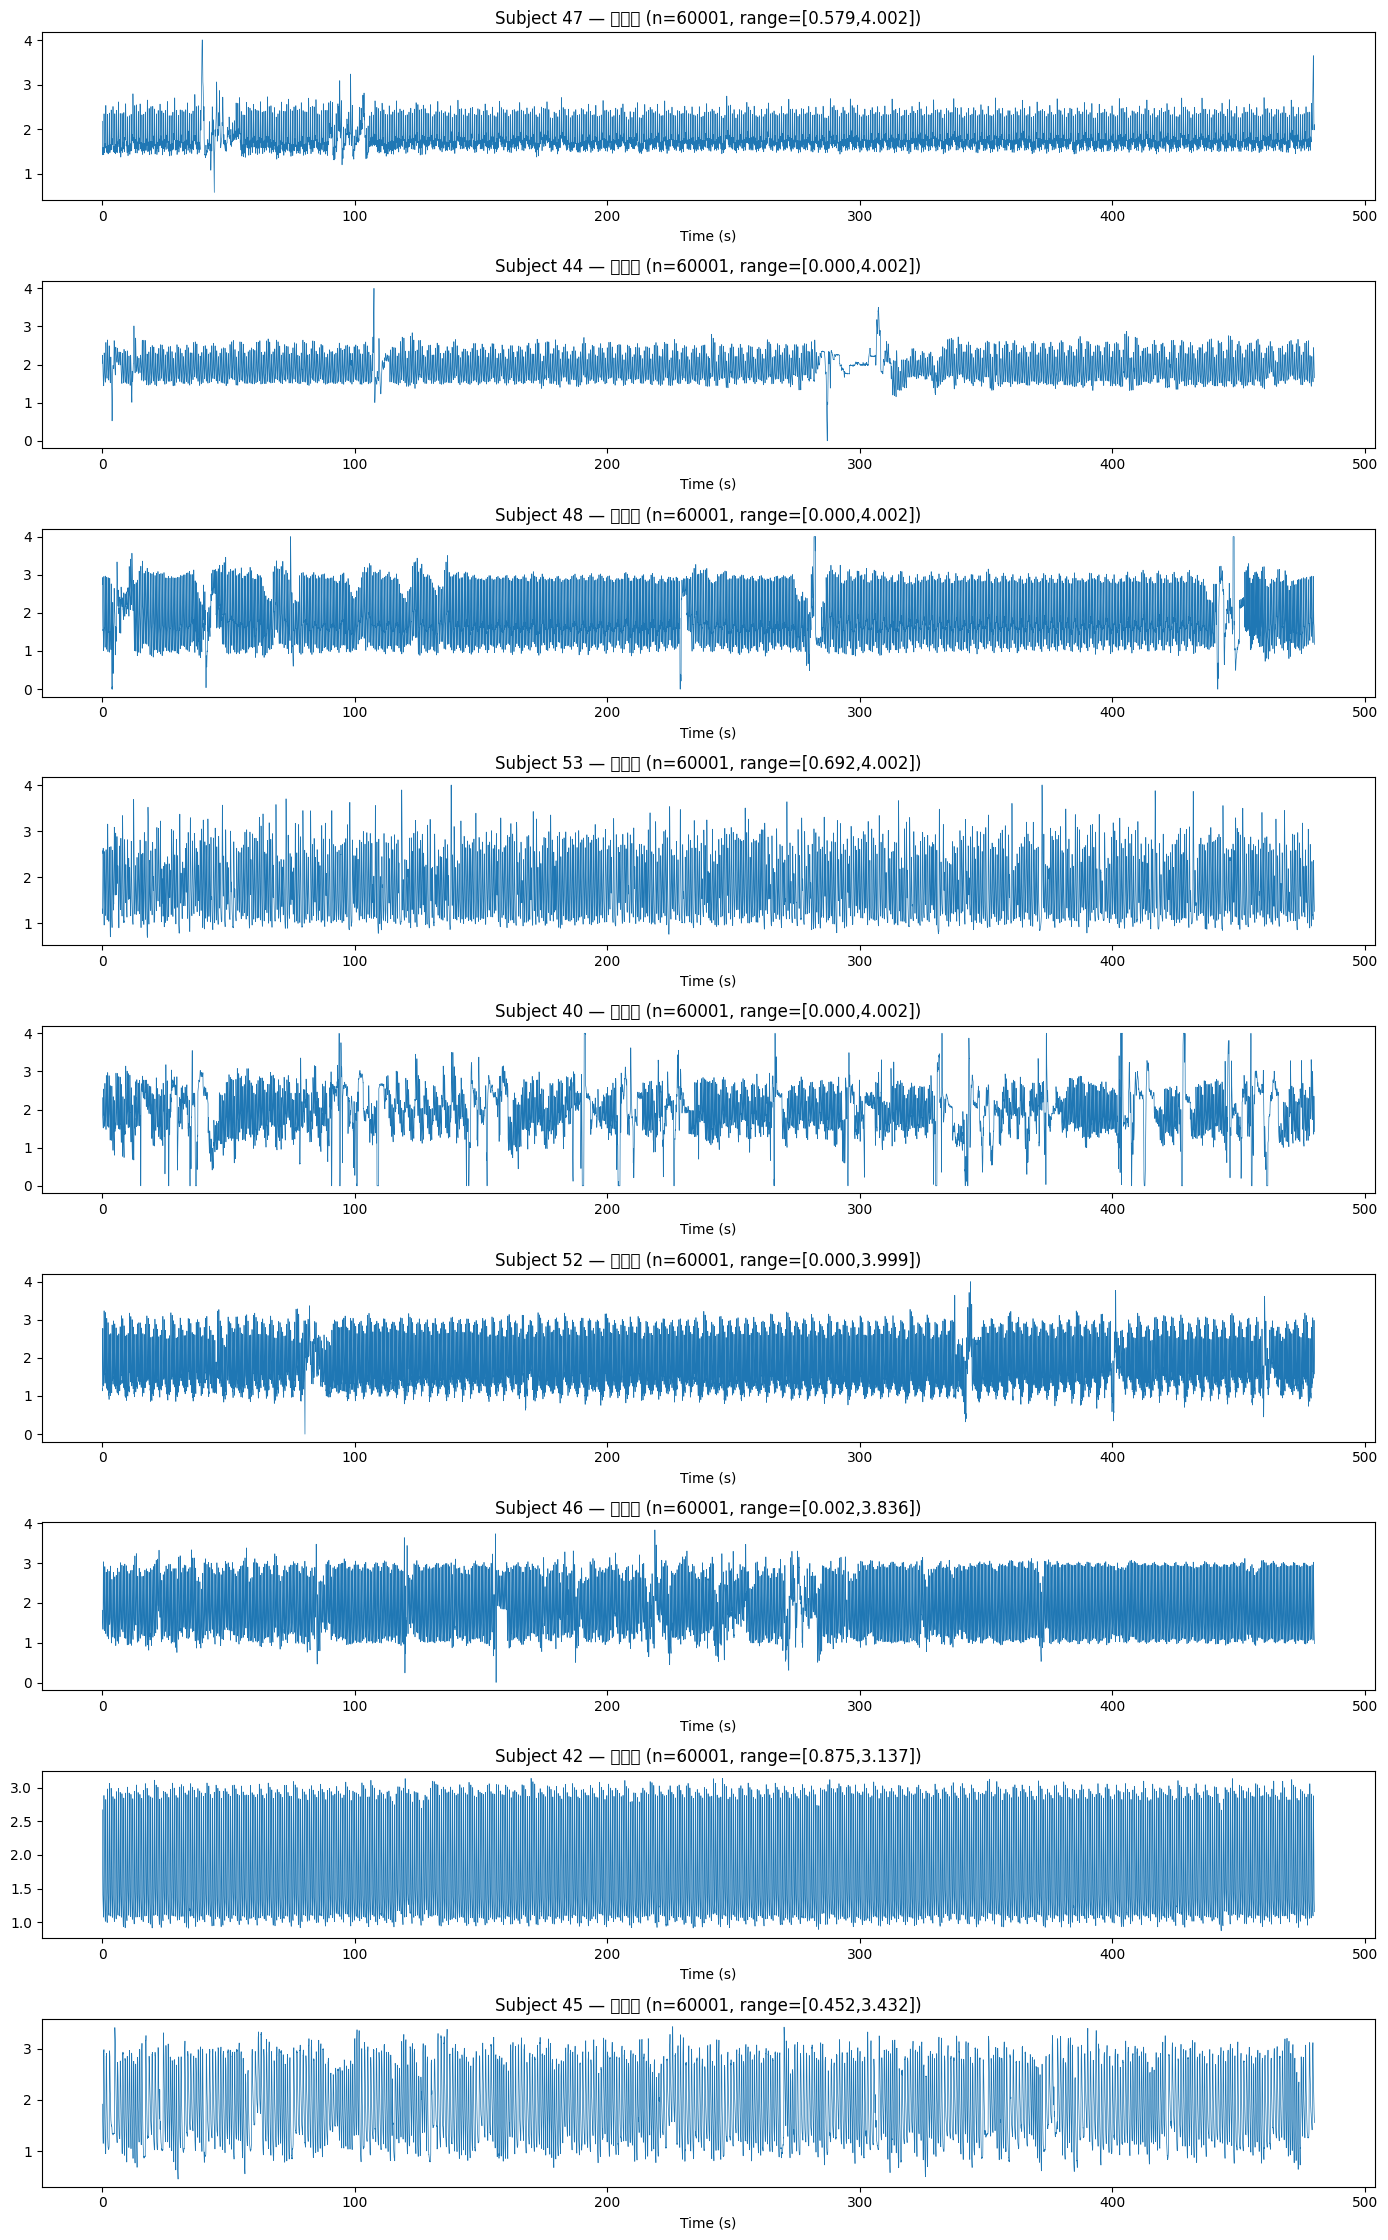

In [69]:
# ============================================================
# 新規セル: 異常レンジ被験者の生波形を直接確認
# ============================================================
anomaly_subjects = [47, 44, 48, 53, 40, 52, 46, 42, 45]

fig, axes = plt.subplots(len(anomaly_subjects), 1, figsize=(14, 2.5*len(anomaly_subjects)))
for ax, sid in zip(axes, anomaly_subjects):
    df = load_signals(sid)
    ppg_full = df[PPG_COL].values.astype(np.float32)
    t = np.arange(len(ppg_full)) / FS
    ax.plot(t, ppg_full, linewidth=0.5)
    ax.set_title(f"Subject {sid} — 全記録 (n={len(ppg_full)}, "
                 f"range=[{ppg_full.min():.3f},{ppg_full.max():.3f}])")
    ax.set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig("/kaggle/working/anomaly_subjects_full_waveform.png", dpi=100)
plt.show()